# Churn Intelligence System v3 — EDA, Preprocesamiento y Entrenamiento

**Proyecto 04** del portafolio de Data Science.

Este notebook cubre el ciclo completo de análisis y modelado:

| # | Sección | Descripción |
|---|---------|-------------|
| 1 | **Carga de datos** | Lectura del CSV, limpieza de `TotalCharges`, primera inspección |
| 2 | **EDA** | Distribución de churn, supervivencia, KDE de cargos, Cramér's V, LTV |
| 3 | **Teoría de la información** | Entropía, MI, MI condicional, información de interacción |
| 4 | **Preprocesamiento** | Pipeline reproducible: `TotalChargesFixer → FeatureEngineer → ColumnTransformer` |
| 5 | **Entrenamiento** | XGBoost con `RandomizedSearchCV` y `StratifiedKFold` |
| 6 | **Evaluación** | Métricas, confusion matrix, ROC, feature importance, **curva de beneficio** |
| 7 | **Explicabilidad** | SHAP summary, waterfall y dependence plots |
| 8 | **MI vs SHAP** | Validación cruzada entre teoría de la información y el modelo |

**Dataset**: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7 043 clientes, 19 features, ~26.5 % tasa de churn.

---

## 1. Setup e Importaciones

In [1]:
%matplotlib inline

import sys, os, warnings
warnings.filterwarnings('ignore')

# Project root on the path
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── Project modules ──────────────────────────────────────────────────────────
from src.config import (
    RAW_CSV, TARGET_COL, ID_COL,
    NUMERIC_FEATURES, BINARY_FEATURES, NOMINAL_FEATURES, FIGURES_DIR,
)
from src.eda import (
    load_raw_data, set_dark_style, churn_rate_summary,
    compute_cramers_v_matrix, estimate_ltv, monthly_churn_loss,
    plot_churn_distribution, plot_tenure_survival,
    plot_monthly_charges_by_churn, plot_contract_churn_rate,
    plot_cramers_heatmap,
    DARK_BG, CYAN, CORAL, AMBER, GREEN, VIOLET, TEXT_COLOR,
    GRID_COLOR, MUTED_COLOR, PALETTE_CHURN,
)
from src.preprocessing import (
    build_full_pipeline, prepare_data, get_feature_names,
    save_pipeline, FeatureEngineer, TotalChargesFixer,
    ALL_NUMERIC, ALL_BINARY, NOMINAL_FEATURES as NOM_FEAT,
    run_mi_feature_diagnostics,
)
from src.information_theory import (
    shannon_entropy, compute_mi_scores,
    compute_conditional_mi_matrix, compute_interaction_matrix,
    select_features_mi,
    plot_entropy_profile, plot_mi_scores,
    plot_conditional_mi_heatmap, plot_interaction_information,
)

# Restore inline backend (some src modules set Agg at import time)
%matplotlib inline
set_dark_style()

print('Imports OK')
print(f'  Project root : {os.path.abspath("..")}')
print(f'  Raw CSV      : {RAW_CSV}')
print(f'  Exists       : {RAW_CSV.exists()}')

Imports OK
  Project root : /home/bllancao/Portafolio/04_classical_ml_and_llm
  Raw CSV      : /home/bllancao/Portafolio/04_classical_ml_and_llm/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
  Exists       : True


## 2. Carga de Datos

El dataset tiene **7 043 filas** y **21 columnas** (19 features + customerID + Churn).

> **Nota técnica**: La columna `TotalCharges` contiene strings de espacios en blanco
> para clientes nuevos (tenure=0). `load_raw_data()` aplica `pd.to_numeric(errors='coerce')`
> para convertirlos a `NaN`, y luego el pipeline los imputa con la mediana.

In [2]:
df = load_raw_data()
print(f'Shape: {df.shape}')
df.head()

2026-03-06 18:20:06.889 | INFO     | src.eda:load_raw_data:94 - Loaded 7043 rows, 21 columns from WA_Fn-UseC_-Telco-Customer-Churn.csv


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Valores faltantes
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print('Columnas con valores faltantes:')
    print(missing)
else:
    print('Sin valores faltantes')

print(f'\nTasa de churn: {df[TARGET_COL].mean():.2%}')
print(f'Clientes total: {len(df):,}')

Columnas con valores faltantes:
TotalCharges    11
dtype: int64

Tasa de churn: 26.54%
Clientes total: 7,043


In [5]:
# Estadísticas descriptivas de features numéricas
df[NUMERIC_FEATURES].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


---
## 3. Análisis Exploratorio de Datos (EDA)

Todas las visualizaciones usan un **tema dark** personalizado
(`DARK_BG=#0a0f18`, `CYAN=#00e5ff`, `CORAL=#ff4f6b`) para calidad de publicación.

### 3.1 Distribución de Churn

,Churn,Count,Percentage
0,No Churn,5174,73.46
1,Churn,1869,26.54


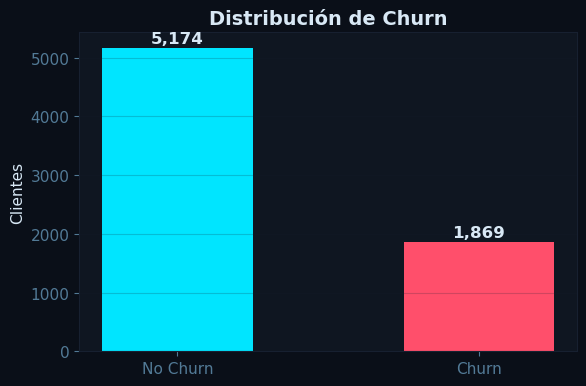

In [6]:
summary = churn_rate_summary(df)
display(summary)

fig = plot_churn_distribution(df, save=False)
plt.show()

### 3.2 Curva de Supervivencia por Tenure

Estilo Kaplan-Meier: la caída abrupta en los primeros 12 meses para
el grupo de churn revela que la **retención temprana es crítica**.

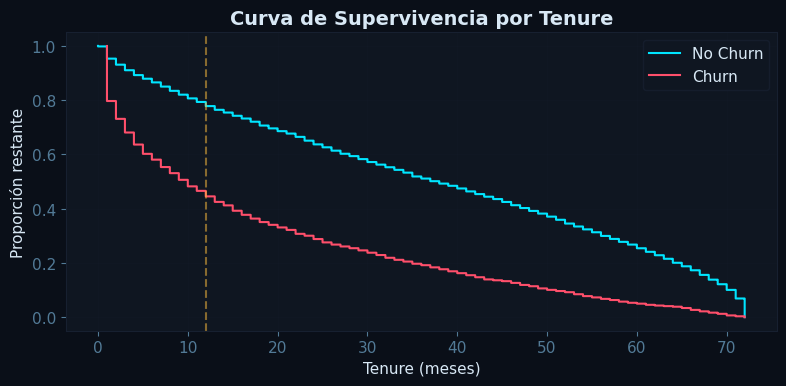

In [7]:
fig = plot_tenure_survival(df, save=False)
plt.show()

### 3.3 Distribución de MonthlyCharges por Churn

Los clientes que abandonan tienden a pagar **cargos mensuales más altos**,
lo que sugiere que están suscritos a más servicios pero no perciben
el valor suficiente para quedarse.

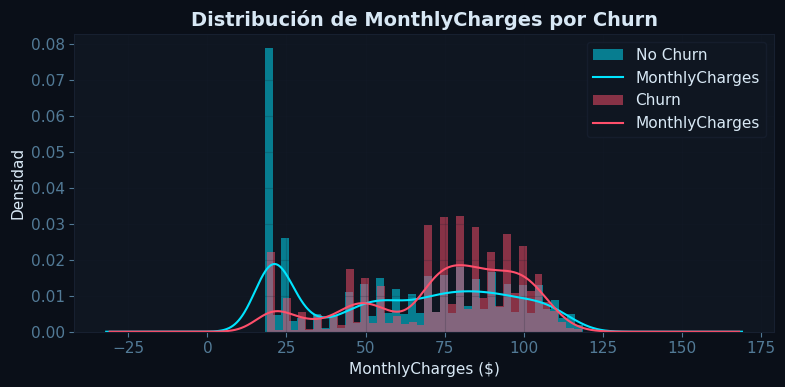

In [8]:
fig = plot_monthly_charges_by_churn(df, save=False)
plt.show()

### 3.4 Tasa de Churn por Tipo de Contrato

El contrato `Month-to-month` tiene una tasa de churn **~4× mayor** que los
contratos anuales. Este es el factor predictivo más fuerte del dataset.

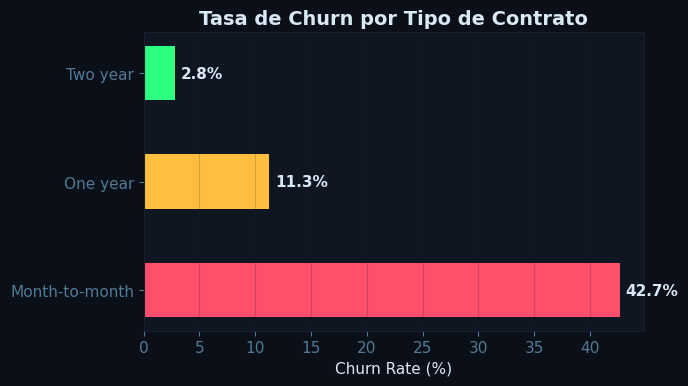

In [9]:
fig = plot_contract_churn_rate(df, save=False)
plt.show()

### 3.5 Cramér's V — Asociaciones Categóricas

Cramér's V mide la fuerza de asociación entre variables categóricas
(con corrección de sesgo de Bergsma 2013). Valores altos entre
`OnlineSecurity`/`TechSupport` y `InternetService` indican colinealidad.

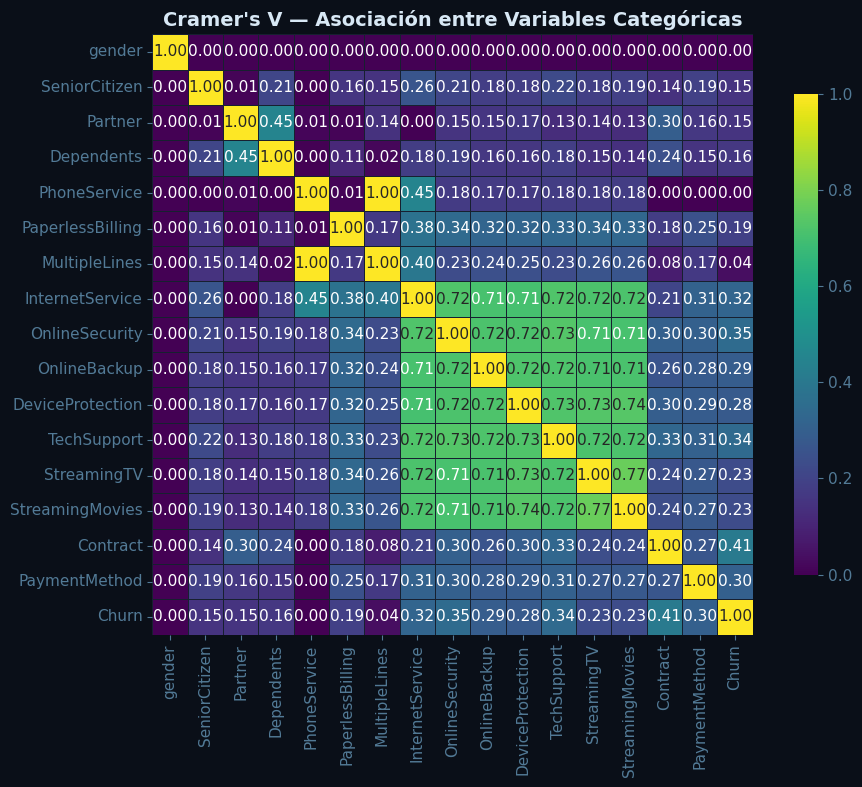

In [10]:
cat_cols = BINARY_FEATURES + NOMINAL_FEATURES + [TARGET_COL]
# Map Churn back to string temporarily for Cramér's V
df_cat = df.copy()
df_cat[TARGET_COL] = df_cat[TARGET_COL].map({0: 'No', 1: 'Yes'})

fig = plot_cramers_heatmap(df_cat, cat_cols, save=False)
plt.show()

### 3.6 Lifetime Value (LTV) y Pérdida Mensual por Churn

LTV estimado = `MonthlyCharges × E[tenure]` por segmento. La **pérdida
anual proyectada** muestra el costo total del churn para el negocio.

In [11]:
ltv = estimate_ltv(df)
display(ltv)

loss = monthly_churn_loss(df)
print('\nPérdida por Churn:')
for k, v in loss.items():
    print(f'  {k}: {v:,.2f}' if isinstance(v, float) else f'  {k}: {v:,}')

,Contract,Churn,avg_monthly,avg_tenure,count,estimated_ltv
0,Month-to-month,No Churn,61.462635,21.033333,2220,1292.76
1,Month-to-month,Churn,73.019396,14.016918,1655,1023.51
2,One year,No Churn,62.508148,41.674063,1307,2604.97
3,One year,Churn,85.050904,44.963855,166,3824.22
4,Two year,No Churn,60.012477,56.602914,1647,3396.88
5,Two year,Churn,86.777083,61.270833,48,5316.90



Pérdida por Churn:
  churned_customers: 1,869
  monthly_loss: 139,130.85
  annual_loss_projected: 1,669,570.20
  avg_monthly_charge_churned: 74.44


---
## 4. Análisis de Teoría de la Información

La teoría de la información proporciona métricas **model-agnostic** para
cuantificar dependencias no lineales entre features y el target.

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| Entropía H(X) | $-\sum p(x) \log p(x)$ | Incertidumbre / contenido informativo |
| MI I(X;Y) | $H(X) + H(Y) - H(X,Y)$ | Dependencia no lineal feature → target |
| CMI I(X;Y\|Z) | $H(X,Z) + H(Y,Z) - H(X,Y,Z) - H(Z)$ | Información residual dado Z |
| II(X₁;X₂;Y) | $I(X₁,X₂;Y) - I(X₁;Y) - I(X₂;Y)$ | Sinergia (+) vs redundancia (−) |

### 4.1 Perfil de Entropía

La entropía de Shannon mide cuánta variabilidad (información) tiene cada feature.
Features con entropía baja aportan poca discriminación.
Variables continuas se discretizan por quantiles antes del cálculo.

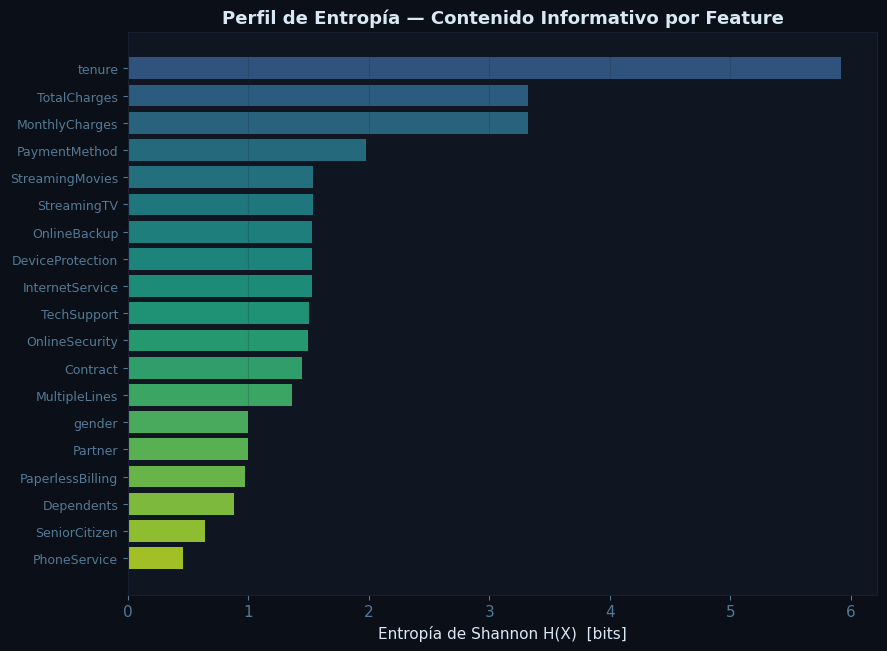

In [12]:
y = df[TARGET_COL].values
X = df.drop(columns=[TARGET_COL, ID_COL], errors='ignore')

fig = plot_entropy_profile(X, save=False)
plt.show()

### 4.2 Información Mutua I(X; Churn)

MI cuantifica cuánta información (en nats) proporciona cada feature sobre
el target. A diferencia de la correlación, **captura dependencias no lineales**.

La línea discontinua roja marca el umbral mínimo (`MI_THRESHOLD = 0.01`).

2026-03-06 18:20:08.043 | INFO     | src.information_theory:compute_mi_scores:379 - MI scores computed for 19 features


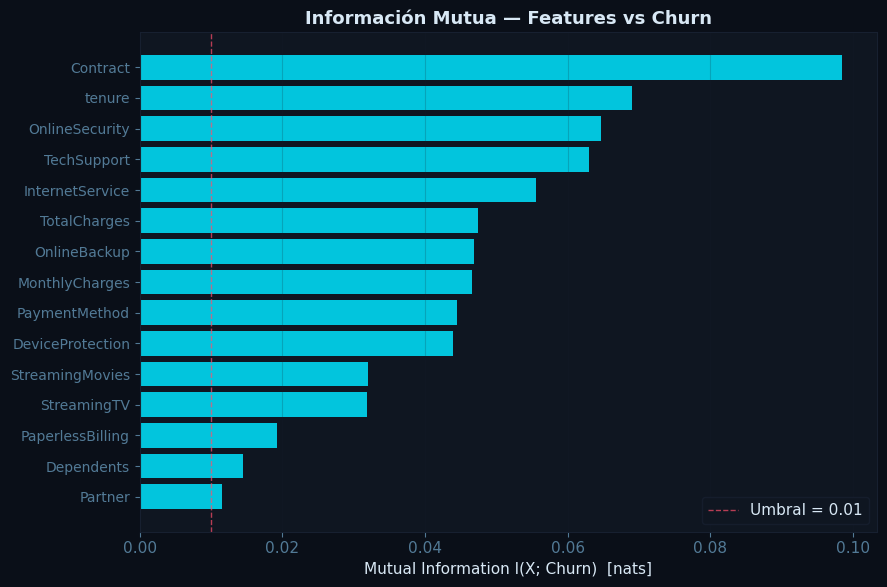


Top 10 features por MI:
Contract            0.098453
tenure              0.069043
OnlineSecurity      0.064677
TechSupport         0.063021
InternetService     0.055574
TotalCharges        0.047488
OnlineBackup        0.046792
MonthlyCharges      0.046515
PaymentMethod       0.044519
DeviceProtection    0.043917


In [13]:
mi_scores = compute_mi_scores(X, y)
fig = plot_mi_scores(mi_scores, save=False)
plt.show()

print('\nTop 10 features por MI:')
print(mi_scores.head(10).to_string())

### 4.3 MI Condicional — I(Xi; Churn | Xj)

La diagonal muestra la MI marginal. Los valores fuera de la diagonal muestran
cuánta MI **queda** después de condicionar en otra feature.

Si `I(Xi; Churn | Xj)` ≈ 0, entonces Xi es **redundante** dado Xj.

2026-03-06 18:20:08.180 | INFO     | src.information_theory:compute_mi_scores:379 - MI scores computed for 19 features
2026-03-06 18:20:09.602 | INFO     | src.information_theory:compute_conditional_mi_matrix:452 - Conditional MI matrix computed for top 10 features


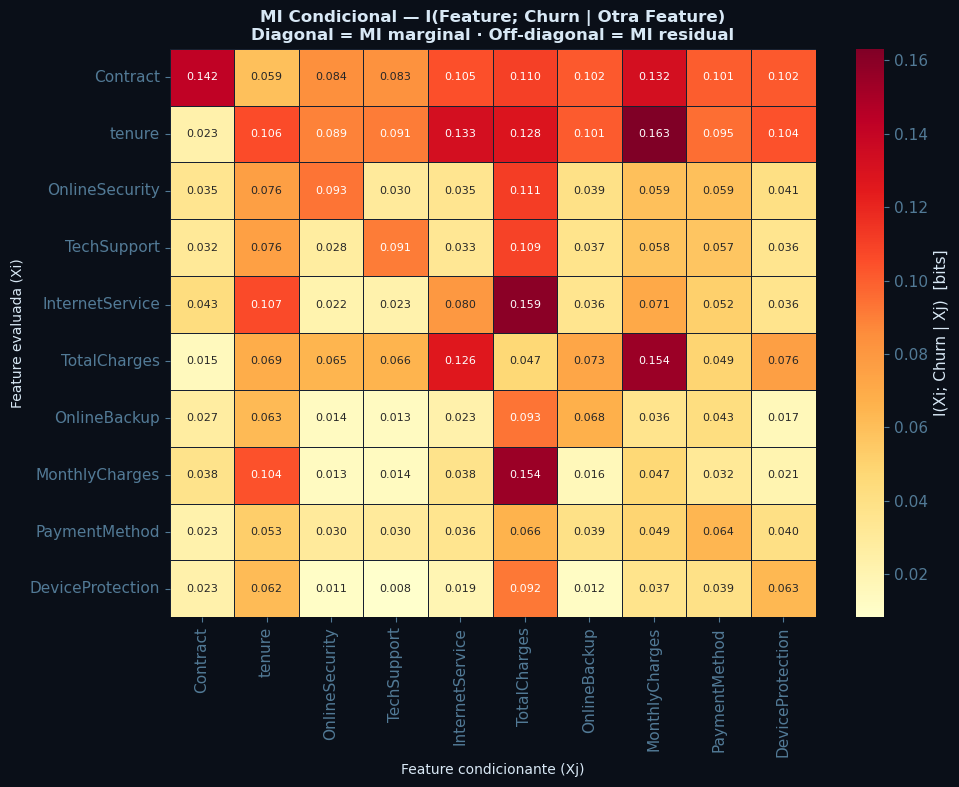

CPU times: user 1.62 s, sys: 12.1 ms, total: 1.63 s
Wall time: 1.63 s


In [14]:
%%time
cmi_matrix = compute_conditional_mi_matrix(X, y, top_k=10)
fig = plot_conditional_mi_heatmap(cmi_matrix, save=False)
plt.show()

### 4.4 Información de Interacción — II(Xi; Xj; Churn)

- **Azul (II > 0)**: Sinergia — las dos features juntas informan más que por separado
- **Rojo (II < 0)**: Redundancia — comparten información sobre el target

Los pares sinérgicos justifican features de interacción en `FeatureEngineer`.

2026-03-06 18:20:09.813 | INFO     | src.information_theory:compute_mi_scores:379 - MI scores computed for 19 features
2026-03-06 18:20:10.207 | INFO     | src.information_theory:compute_interaction_matrix:517 - Interaction Information matrix computed for top 8 features


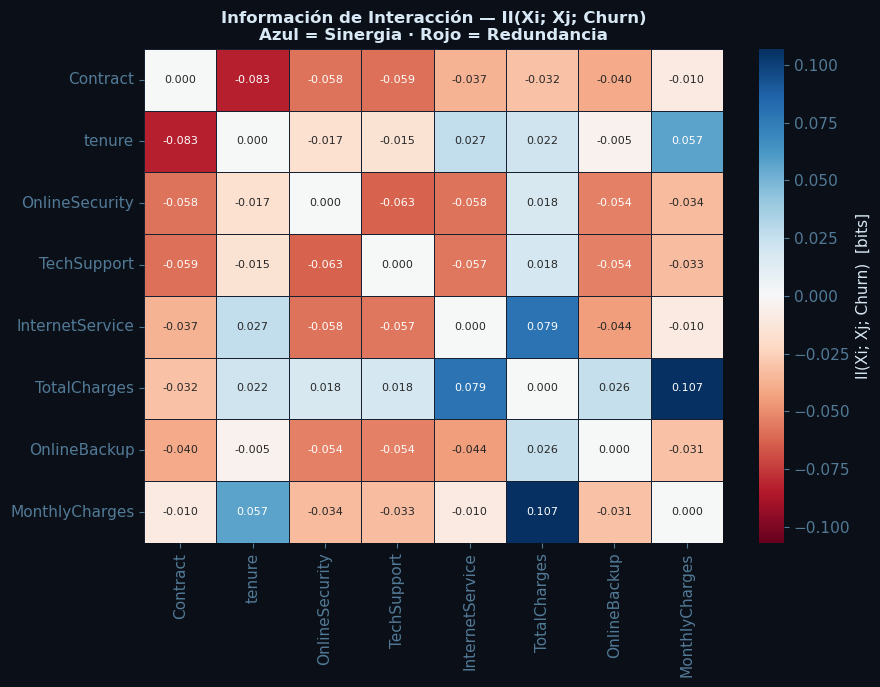

CPU times: user 563 ms, sys: 5 ms, total: 568 ms
Wall time: 567 ms


In [15]:
%%time
ii_matrix = compute_interaction_matrix(X, y, top_k=8)
fig = plot_interaction_information(ii_matrix, save=False)
plt.show()

---
## 5. Preprocesamiento

El pipeline de preprocesamiento es **el artefacto central** del sistema:
se serializa una vez en entrenamiento y se reutiliza en API, agente y monitoreo.

```
TotalChargesFixer → FeatureEngineer → ColumnTransformer
                                        ├── num: Imputer + StandardScaler
                                        ├── bin: OrdinalEncoder
                                        └── nom: OneHotEncoder
```

`FeatureEngineer` crea **13 features derivadas** (5 originales + 8 de interacción):

| Feature | Tipo | Señal capturada |
|---------|------|----------------|
| `charges_per_tenure` | Numérica | Tasa de extracción de valor — clientes nuevos pagando mucho |
| `service_count` | Numérica | Stickiness — más servicios = mayor costo de cambio |
| `is_new_customer` | Binaria | Zona de peligro: primeros 6 meses |
| `high_value_flag` | Binaria | Clientes con MonthlyCharges > $70 |
| `total_charges_ratio` | Numérica | Anomalías de facturación (descuentos, upgrades) |
| `monthly_contract` | Binaria | **[v1]** Flag explícito mes-a-mes (~43% churn rate) |
| `fiber_unprotected` | Binaria | **[v1]** Fiber + sin OnlineSecurity + sin TechSupport (~50% churn) |
| `early_monthly` | Binaria | **[v1]** Mes-a-mes AND tenure ≤ 12 (~55% churn — segmento de mayor riesgo) |
| `no_sticky_count` | Numérica | **[v1]** Cuenta servicios de valor sin activar (0–4) |
| `charge_risk_score` | Numérica | **[v1]** MonthlyCharges × (1/tenure+1) × mes-a-mes — riesgo compuesto |
| `charges_efficiency` | Numérica | **[v2]** TotalCharges / (MonthlyCharges × tenure+1) — razón cobro real vs esperado |
| `overloaded_monthly` | Binaria | **[v2]** service_count ≥ 4 AND mes-a-mes — paradoja de retención (~42% churn) |
| `highest_risk` | Binaria | **[v2]** fiber_unprotected AND early_monthly — intersección de segmentos críticos (~60% churn) |


In [16]:
# Construir y ajustar el pipeline completo
X_transformed, y, pipeline = prepare_data(df)

feature_names = get_feature_names(pipeline)
print(f'Shape transformada: {X_transformed.shape}')
print(f'Features de salida: {len(feature_names)}')
print(f'\nNombres de features:')
for i, name in enumerate(feature_names):
    print(f'  [{i:2d}] {name}')

2026-03-06 18:20:10.389 | INFO     | src.preprocessing:prepare_data:453 - Pipeline fitted — output shape: (7043, 54)


Shape transformada: (7043, 54)
Features de salida: 54

Nombres de features:
  [ 0] num__tenure
  [ 1] num__MonthlyCharges
  [ 2] num__TotalCharges
  [ 3] num__charges_per_tenure
  [ 4] num__service_count
  [ 5] num__total_charges_ratio
  [ 6] num__no_sticky_count
  [ 7] num__charge_risk_score
  [ 8] num__charges_efficiency
  [ 9] bin__gender
  [10] bin__SeniorCitizen
  [11] bin__Partner
  [12] bin__Dependents
  [13] bin__PhoneService
  [14] bin__PaperlessBilling
  [15] bin__is_new_customer
  [16] bin__high_value_flag
  [17] bin__monthly_contract
  [18] bin__fiber_unprotected
  [19] bin__early_monthly
  [20] bin__overloaded_monthly
  [21] bin__highest_risk
  [22] bin__echeck_monthly
  [23] bin__senior_monthly
  [24] bin__digital_risk
  [25] nom__MultipleLines_No
  [26] nom__MultipleLines_No phone service
  [27] nom__MultipleLines_Yes
  [28] nom__InternetService_DSL
  [29] nom__InternetService_Fiber optic
  [30] nom__InternetService_No
  [31] nom__OnlineSecurity_No
  [32] nom__OnlineSecu

In [17]:
# ── Verificacion: no deben existir Inf/NaN tras FeatureEngineer ────────────
# TotalChargesFixer ahora imputa tenure==0 con MonthlyCharges (no mediana),
# por lo que charges_per_tenure y charge_risk_score no pueden producir inf.
# Esta celda falla ruidosamente si se introduce alguna regresion.
import numpy as np

n_inf = int(np.isinf(X_transformed).sum())
n_nan = int(np.isnan(X_transformed).sum())

print(f"Inf values in X_transformed: {n_inf}")
print(f"NaN values in X_transformed: {n_nan}")

assert n_inf == 0, f"FAIL: {n_inf} Inf values found in X_transformed"
assert n_nan == 0, f"FAIL: {n_nan} NaN values found in X_transformed"
print("OK: X_transformed is finite and complete.")

Inf values in X_transformed: 0
NaN values in X_transformed: 0
OK: X_transformed is finite and complete.


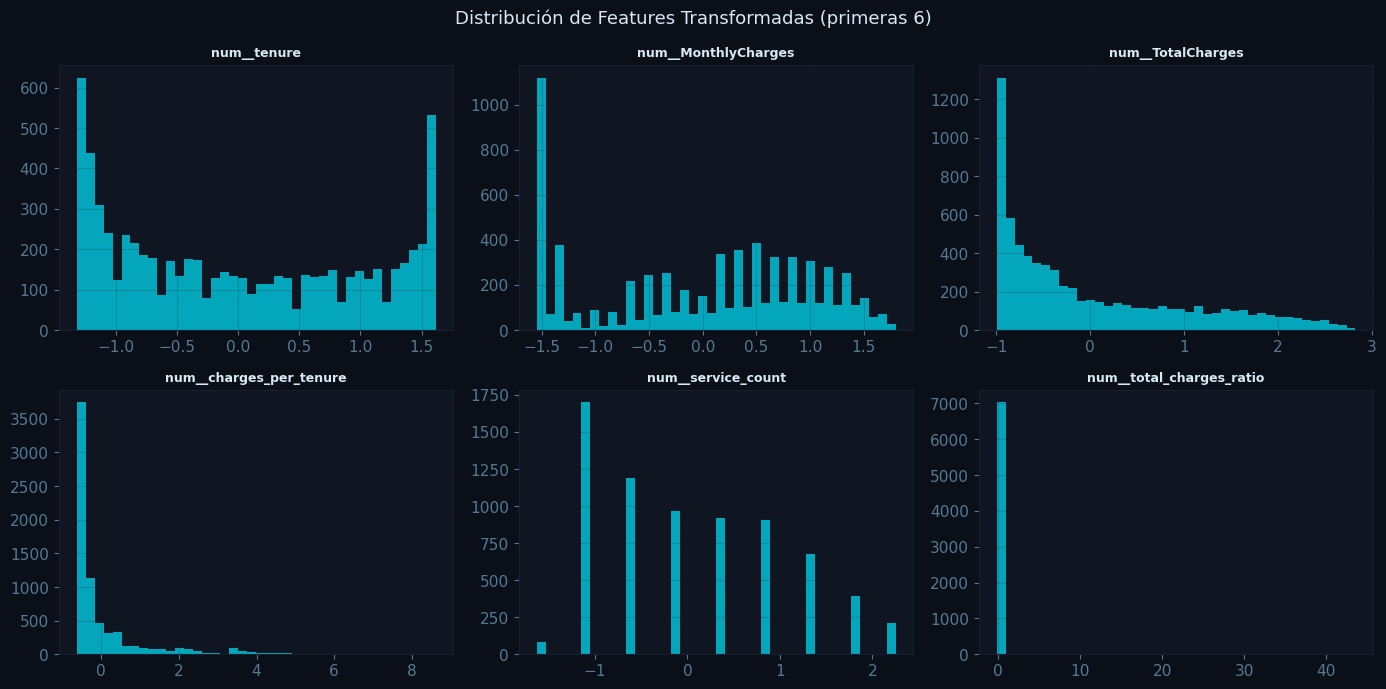

In [18]:
# Visualizar la distribución de features transformadas (primeras 6)
set_dark_style()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for idx, ax in enumerate(axes.flat):
    if idx >= X_transformed.shape[1]:
        ax.set_visible(False)
        continue
    name = feature_names[idx] if idx < len(feature_names) else f'feat_{idx}'
    ax.hist(X_transformed[:, idx], bins=40, color=CYAN, alpha=0.7, edgecolor='none')
    ax.set_title(name, fontsize=9)
    ax.grid(alpha=0.2)

fig.suptitle('Distribución de Features Transformadas (primeras 6)', fontsize=13, color=TEXT_COLOR)
plt.tight_layout()
plt.show()

---
## 6. Entrenamiento — XGBoost

Entrenamos un **XGBClassifier** con búsqueda de hiperparámetros via
`RandomizedSearchCV` y `StratifiedKFold(5)`.

Decisiones clave para manejar el desbalance de clases (~26.5% Churn):

| Técnica | Justificación |
|---------|--------------|
| **`scale_pos_weight`** explorado en `[1.0, 1.5, 2.0, ratio]` | `spw=1.0` fijo dejaba que el gradiente tratara FN y FP como igualmente costosos — no óptimo para distribución 73/27. Explorar `{1.5, 2.0, ratio≈2.77}` permite que el CV con `f1_macro` encuentre el balance P/R óptimo **dentro** del entrenamiento, no solo con el umbral |
| **`scoring='f1_macro'`** | Promedia F1 de ambas clases por igual — evalúa al threshold de decisión, evitando que recall alto a costa de precisión gane en CV |
| **Regularización `gamma`, `reg_alpha`, `reg_lambda`** | Controla la complejidad de los árboles y previene overfitting |
| **`n_iter=120`** | Más iteraciones de la búsqueda aleatoria para explorar mejor el espacio ampliado |
| **Split 80/20 sin hold-out adicional** | El umbral óptimo se estima via OOF (`cross_val_predict`) sobre `X_train` completo, eliminando la necesidad de apartar un conjunto de validación separado |

> **Por qué OOF en lugar de hold-out para el umbral**: un hold-out del 12% (675 samples / ~179 positivos) produce una curva F1-Macro por threshold muy ruidosa. Las predicciones OOF sobre los ~5.6K samples de train (~1.5K positivos) dan una curva mucho más estable.

> **Por qué no SMOTE**: introduciría doble manejo del desbalance junto con `scale_pos_weight`, haciendo al modelo extremadamente agresivo en predecir churn.

> **Ceiling del dataset**: ~7 043 filas. Con ML clásico + feature engineering el techo práctico es F1-Macro ~0.76–0.82.


In [19]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score,
)
from xgboost import XGBClassifier

# ── Train / Test split (80/20) ───────────────────────────────────────────────
# El threshold óptimo se determina via OOF (cross_val_predict) sobre X_train,
# por lo que NO se necesita apartar un hold-out adicional.
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42, stratify=y,
)

print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')
print(f'Features: {X_train.shape[1]}')
print(f'Churn rate (train): {y_train.mean():.2%}')
print(f'Churn rate (test):  {y_test.mean():.2%}')


Train: 5,634 samples
Test:  1,409 samples
Features: 54
Churn rate (train): 26.54%
Churn rate (test):  26.54%


In [20]:
%%time
# ── Clase ratio real: neg/pos ≈ 2.77 ──
class_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class ratio neg/pos: {class_ratio:.2f}')

# ── scale_pos_weight: se explora en CV junto con el resto de hiperparámetros ──
# spw=1.0 trata FN igual que FP → la frontera de decisión aprendida no está
# optimizada para distribución 73/27. Incluir spw ∈ {1.5, 2.0, ratio} permite
# que el CV con scoring='roc_auc' optimice ranking (AUC); el umbral post-entreno
# optimiza F1-Macro via OOF, desacoplando ambos objetivos.
xgb_params = {
    'n_estimators':     [100, 200, 300, 400, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.08, 0.1, 0.15],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.05, 0.1, 0.2, 0.3],
    'reg_alpha':        [0, 0.01, 0.05, 0.1, 0.5],
    'reg_lambda':       [0.5, 1.0, 1.5, 2.0],
    'scale_pos_weight': [1.0, 1.5, 2.0, class_ratio],  # explorar balance P/R en CV
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_params,
    n_iter=60,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print(f'\nBest CV F1-Macro: {search.best_score_:.4f}')
print(f'Best params:')
for k, v in sorted(search.best_params_.items()):
    print(f'  {k}: {v}')


Class ratio neg/pos: 2.77
Fitting 15 folds for each of 60 candidates, totalling 900 fits

Best CV F1-Macro: 0.8498
Best params:
  colsample_bytree: 0.9
  gamma: 0.3
  learning_rate: 0.01
  max_depth: 3
  min_child_weight: 1
  n_estimators: 500
  reg_alpha: 0.5
  reg_lambda: 1.5
  scale_pos_weight: 1.5
  subsample: 0.8
CPU times: user 2min 45s, sys: 451 ms, total: 2min 46s
Wall time: 41.9 s


---
## 7. Evaluación del Modelo

In [21]:
# ── Predictions ──
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# ── Metrics ──
metrics = {
    'ROC-AUC':   roc_auc_score(y_test, y_proba),
    'F1-Macro':  f1_score(y_test, y_pred, average='macro'),
    'F1-Churn':  f1_score(y_test, y_pred, average='binary'),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'Accuracy':  accuracy_score(y_test, y_pred),
}

print('Métricas en Test Set:')
print('=' * 35)
for name, val in metrics.items():
    print(f'  {name:12s}: {val:.4f}')

print('\nClassification Report (macro avg):')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Métricas en Test Set:
  ROC-AUC     : 0.8491
  F1-Macro    : 0.7349
  F1-Churn    : 0.6173
  Precision   : 0.5902
  Recall      : 0.6471
  Accuracy    : 0.7871

Classification Report (macro avg):
              precision    recall  f1-score   support

    No Churn       0.87      0.84      0.85      1035
       Churn       0.59      0.65      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.79      0.79      1409



### 7.0 Optimización de Umbral — argmax F1-Macro con OOF predictions

Con ROC-AUC ~0.84 el modelo tiene buena separabilidad, pero el umbral por defecto (0.5)
puede no maximizar F1-Macro en datasets desbalanceados.

**Por qué `argmax F1-Macro` directo (no F_β)**:
F_β(β<1) sesga el umbral hacia precisión sin maximizar la métrica de comparación.
El cambio directo: evaluar F1-Macro exactamente en cada umbral.

**Por qué OOF (no hold-out ni test set)**:

| Enfoque | Samples para estimar umbral | Positivos | Ruido |
|---------|----------------------------|-----------|-------|
| Test set (leakage) | ~1.4K | ~373 | Bajo pero **contaminado** |
| Hold-out 12% | ~675 | ~179 | **Alto** — curva espuria |
| OOF 5-fold (✅) | ~5.6K | ~1.5K | Bajo, sin leakage |

`cross_val_predict` genera predicciones OOF: cada sample se predice cuando su fold está fuera del entrenamiento. Sin leakage, usa todo `X_train`, curva F1-Macro estable.

$$t^* = \arg\max_{t} \frac{F1_{\text{No Churn}}^{\text{OOF}}(t) + F1_{\text{Churn}}^{\text{OOF}}(t)}{2}$$


In [22]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict

# ── Threshold Optimization — argmax F1-Macro con OOF predictions ─────────────
# cross_val_predict genera predicciones OOF sobre X_train:
#   - Cada muestra se predice cuando su fold estaba fuera del entrenamiento→ sin leakage
#   - Usa TODOS los datos de train para estimar el umbral (~5.6K samples, ~1.5K positivos)
#     vs un hold-out de 675/179 → curva F1-Macro mucho más estable
# El modelo final reportado se aplica sobre X_test (nunca visto en todo el proceso).
print('Calculando OOF predictions (5-fold)...')
y_proba_oof = cross_val_predict(
    best_model,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

thresholds_eval = np.linspace(0.05, 0.95, 500)
f1_macros_eval  = [
    f1_score(y_train, (y_proba_oof >= t).astype(int), average='macro', zero_division=0)
    for t in thresholds_eval
]
optimal_thresh = thresholds_eval[np.argmax(f1_macros_eval)]

# Probabilidades finales sobre test con el modelo entrenado en TODO X_train
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= optimal_thresh).astype(int)

# Baseline a umbral 0.5 para comparar
y_pred_05  = (y_proba >= 0.5).astype(int)
metrics_05 = {
    'ROC-AUC':   roc_auc_score(y_test, y_proba),
    'F1-Macro':  f1_score(y_test, y_pred_05, average='macro'),
    'F1-Churn':  f1_score(y_test, y_pred_05, average='binary'),
    'Precision': precision_score(y_test, y_pred_05, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_05),
    'Accuracy':  accuracy_score(y_test, y_pred_05),
}

metrics = {
    'ROC-AUC':   roc_auc_score(y_test, y_proba),
    'F1-Macro':  f1_score(y_test, y_pred, average='macro'),
    'F1-Churn':  f1_score(y_test, y_pred, average='binary'),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall':    recall_score(y_test, y_pred),
    'Accuracy':  accuracy_score(y_test, y_pred),
}

print(f'Umbral óptimo (argmax F1-Macro OOF): {optimal_thresh:.3f}')
print(f'{"Métrica":12s}  {"Default (0.5)":>14s}  {"OOF Óptimo":>14s}  {"Δ":>8s}')
print('─' * 57)
for name in metrics:
    v0 = metrics_05[name]
    v1 = metrics[name]
    print(f'  {name:12s}  {v0:14.4f}  {v1:14.4f}  {v1-v0:+8.4f}')

print(f'\n→ Usando umbral OOF óptimo {optimal_thresh:.3f} para las secciones siguientes.')


Calculando OOF predictions (5-fold)...
Umbral óptimo (argmax F1-Macro OOF): 0.499
Métrica        Default (0.5)      OOF Óptimo         Δ
─────────────────────────────────────────────────────────
  ROC-AUC               0.8491          0.8491   +0.0000
  F1-Macro              0.7349          0.7353   +0.0004
  F1-Churn              0.6173          0.6183   +0.0010
  Precision             0.5902          0.5898   -0.0004
  Recall                0.6471          0.6497   +0.0027
  Accuracy              0.7871          0.7871   +0.0000

→ Usando umbral OOF óptimo 0.499 para las secciones siguientes.


### 7.1 Confusion Matrix

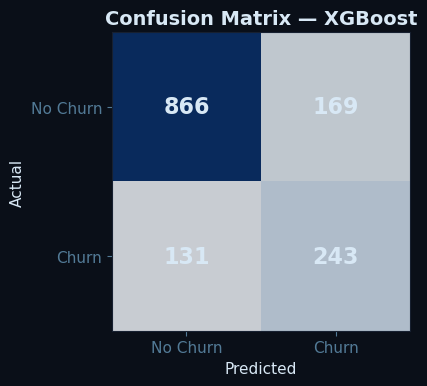

In [23]:
from src.train import plot_confusion_matrix

fig = plot_confusion_matrix(y_test, y_pred, 'XGBoost')
plt.show()

### 7.2 Curva ROC y Curva Precisión-Recall

La **Curva PR** es la métrica de referencia en datasets desbalanceados:
un modelo que predice siempre la clase mayoritaria tiene AUC-ROC ~0.5 pero PR-AUC ≈ prevalencia (~0.265),
lo que la hace mucho más discriminante.


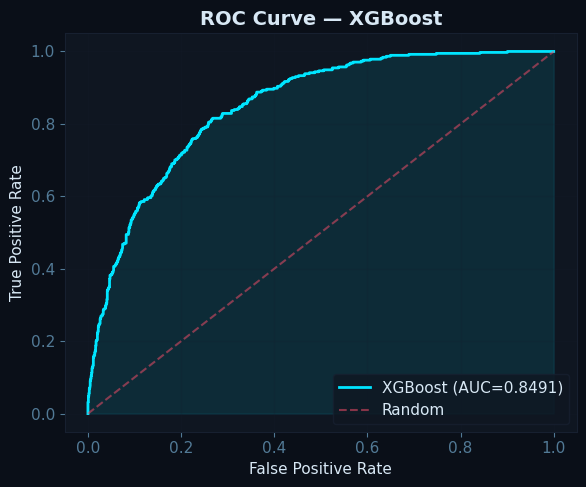

In [24]:
from src.train import plot_roc_curve

fig = plot_roc_curve(y_test, y_proba, 'XGBoost', metrics['ROC-AUC'])
plt.show()

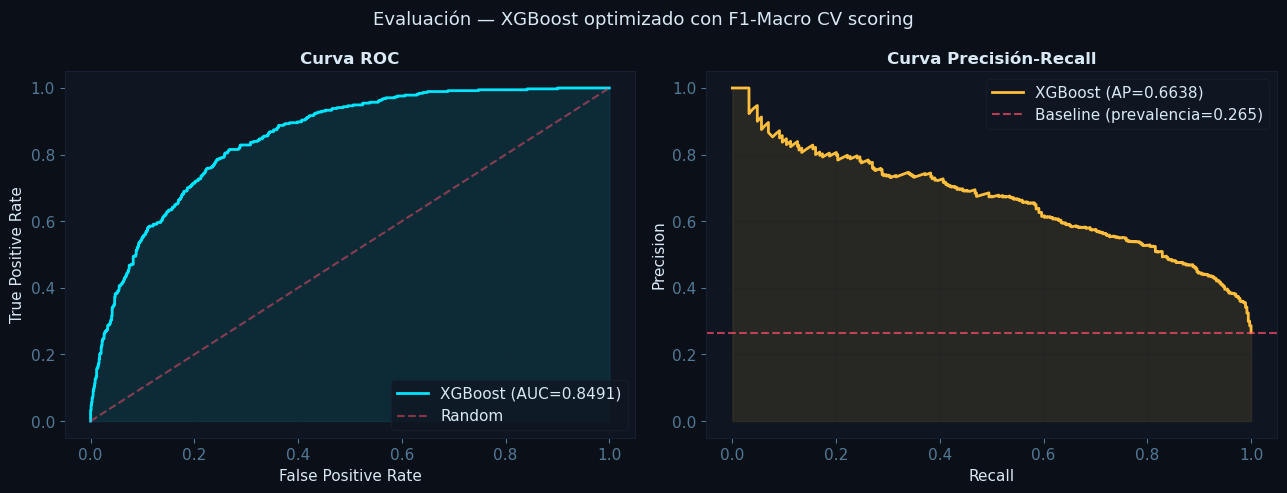

Average Precision Score: 0.6638
Prevalencia (baseline PR): 0.2654
Lift sobre baseline: 2.50×


In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from src.eda import set_dark_style, CYAN, CORAL, AMBER, TEXT_COLOR, DARK_BG

set_dark_style()
ap_score = average_precision_score(y_test, y_proba)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC ──
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color=CYAN, linewidth=2, label=f'XGBoost (AUC={metrics["ROC-AUC"]:.4f})')
axes[0].plot([0, 1], [0, 1], color=CORAL, linestyle='--', alpha=0.5, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color=CYAN)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC', fontsize=12, color=TEXT_COLOR)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.2)

# ── PR ──
axes[1].plot(recall_vals, precision_vals, color=AMBER, linewidth=2,
             label=f'XGBoost (AP={ap_score:.4f})')
axes[1].axhline(y=(y_test == 1).mean(), color=CORAL, linestyle='--', alpha=0.7,
                label=f'Baseline (prevalencia={( y_test==1).mean():.3f})')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color=AMBER)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precisión-Recall', fontsize=12, color=TEXT_COLOR)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.2)

fig.suptitle('Evaluación — XGBoost optimizado con F1-Macro CV scoring', fontsize=13, color=TEXT_COLOR)
plt.tight_layout()
plt.show()

print(f'Average Precision Score: {ap_score:.4f}')
print(f'Prevalencia (baseline PR): {(y_test == 1).mean():.4f}')
print(f'Lift sobre baseline: {ap_score / (y_test == 1).mean():.2f}×')


### 7.3 Feature Importance

Importancia basada en el **gain** del modelo XGBoost.
Los nombres de features incluyen prefijos del `ColumnTransformer`
(`num__`, `bin__`, `nom__`).

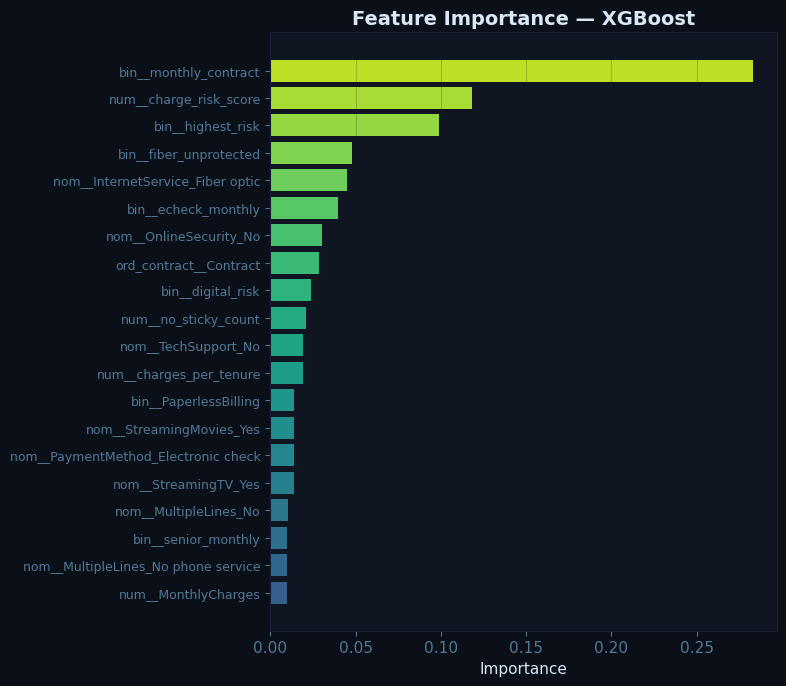

In [26]:
from src.train import plot_feature_importance

fig = plot_feature_importance(best_model, feature_names, 'XGBoost', top_n=20)
if fig:
    plt.show()

### 7.4 Curva de Beneficio (Profit Curve)

A diferencia de métricas estándar (F1, AUC), la curva de beneficio traduce
las predicciones a **impacto financiero**:

- **Beneficio por True Positive**: $200 (retener un cliente que iba a abandonar)
- **Costo por False Positive**: $15 (contactar a un cliente que no iba a abandonar)

El **umbral óptimo** maximiza el beneficio total.

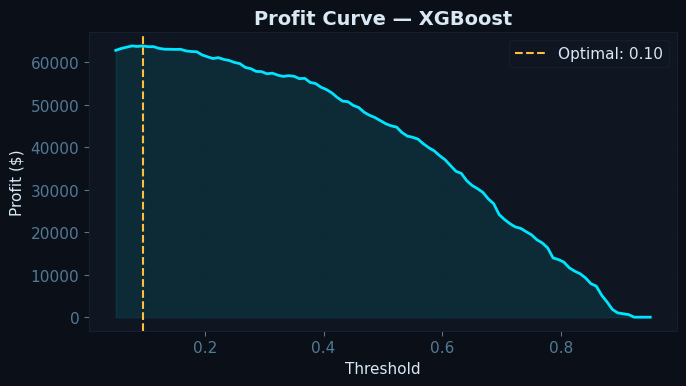

Umbral óptimo: 0.10
Beneficio máximo: $63,805

Métricas con umbral óptimo (0.10):
  F1:        0.5399
  Precision: 0.3732
  Recall:    0.9759


In [27]:
from src.train import compute_profit_curve, plot_profit_curve

thresholds, profits, optimal_threshold = compute_profit_curve(y_test, y_proba)

fig = plot_profit_curve(thresholds, profits, optimal_threshold, 'XGBoost')
plt.show()

print(f'Umbral óptimo: {optimal_threshold:.2f}')
print(f'Beneficio máximo: ${np.max(profits):,.0f}')

# Métricas con el umbral óptimo
y_pred_opt = (y_proba >= optimal_threshold).astype(int)
print(f'\nMétricas con umbral óptimo ({optimal_threshold:.2f}):')
print(f'  F1:        {f1_score(y_test, y_pred_opt):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_opt):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_opt):.4f}')

---
## 8. Explicabilidad — SHAP

SHAP (SHapley Additive exPlanations) descompone cada predicción en
contribuciones por feature, basándose en la teoría de juegos cooperativos.

- **Global**: ¿Qué features importan más en general?
- **Local**: ¿Por qué este cliente específico tiene riesgo alto/bajo?

In [28]:
import shap

# Build TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Para clasificadores binarios, shap_values puede ser una lista [class_0, class_1]
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values = shap_values[1]

# Build Explanation object
base_value = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

explanation = shap.Explanation(
    values=shap_values,
    base_values=base_value,
    data=X_test,
    feature_names=feature_names,
)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Base value (log-odds): {base_value:.4f}')

SHAP values shape: (1409, 54)
Base value (log-odds): -0.6139


### 8.1 SHAP Summary Plot (Global)

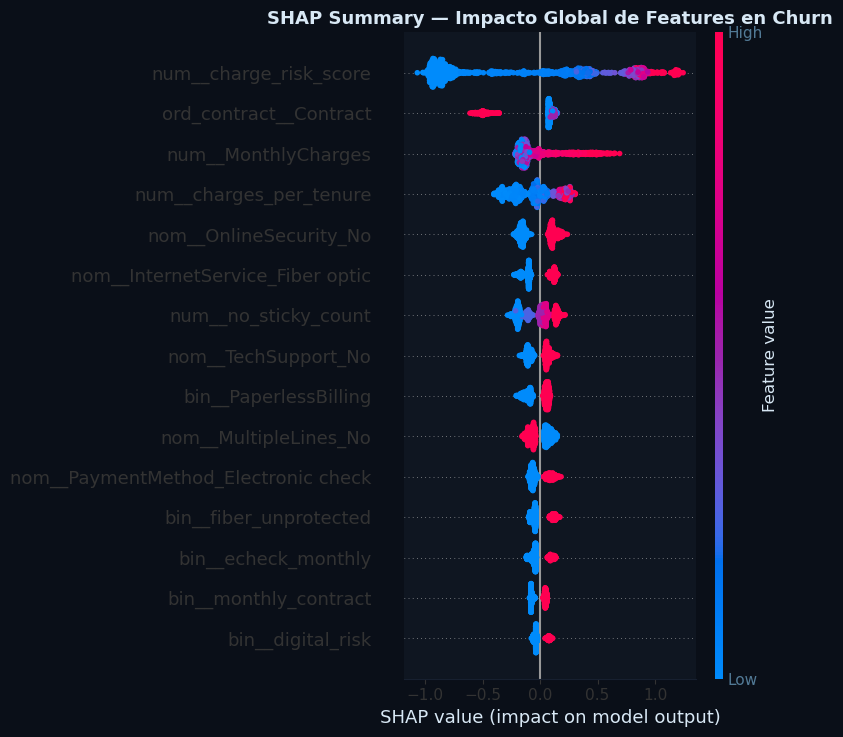

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    show=False, max_display=15,
)
plt.title('SHAP Summary — Impacto Global de Features en Churn', fontsize=13, color=TEXT_COLOR)
plt.tight_layout()
plt.show()

### 8.2 SHAP Waterfall — Explicación Local

Waterfall de un cliente con **alto riesgo** y otro con **bajo riesgo**.

Alto riesgo — idx=1090, P(churn)=0.9213
Bajo riesgo — idx=1344, P(churn)=0.0156


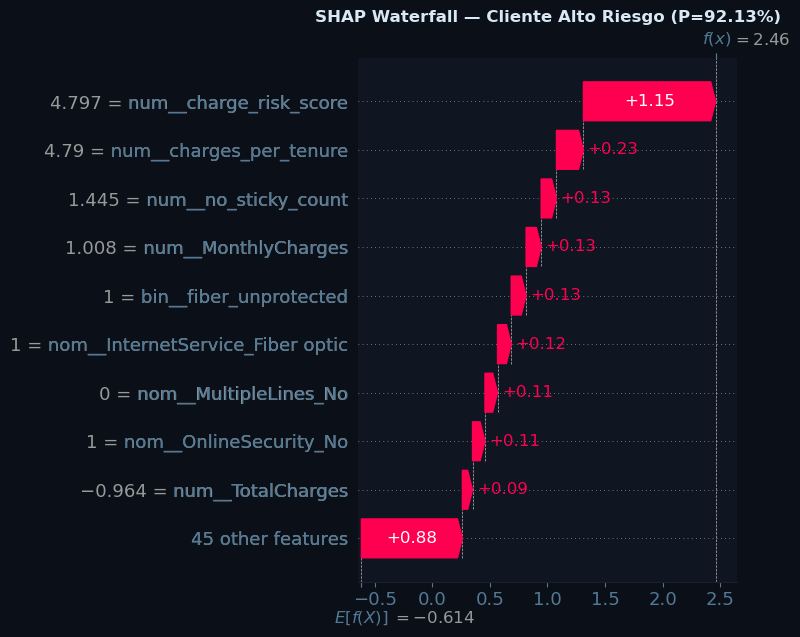

In [30]:
# Encontrar un cliente de alto riesgo y uno de bajo riesgo
high_risk_idx = np.argmax(y_proba)
low_risk_idx = np.argmin(y_proba)

print(f'Alto riesgo — idx={high_risk_idx}, P(churn)={y_proba[high_risk_idx]:.4f}')
print(f'Bajo riesgo — idx={low_risk_idx}, P(churn)={y_proba[low_risk_idx]:.4f}')

# High risk waterfall
fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation[high_risk_idx], show=False, max_display=10)
plt.title(f'SHAP Waterfall — Cliente Alto Riesgo (P={y_proba[high_risk_idx]:.2%})', fontsize=12)
plt.tight_layout()
plt.show()

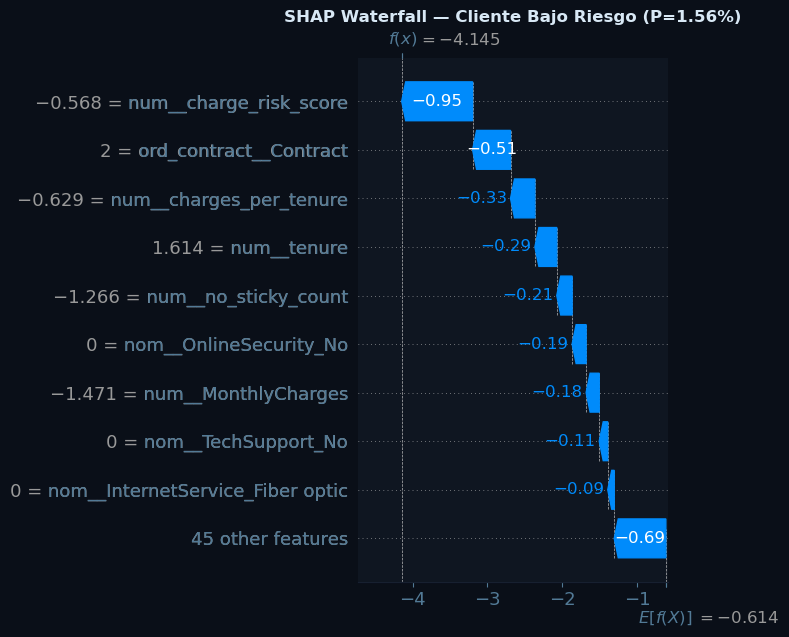

In [31]:
# Low risk waterfall
fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation[low_risk_idx], show=False, max_display=10)
plt.title(f'SHAP Waterfall — Cliente Bajo Riesgo (P={y_proba[low_risk_idx]:.2%})', fontsize=12)
plt.tight_layout()
plt.show()

### 8.3 SHAP Dependence Plot

Muestra cómo el valor de una feature afecta su contribución SHAP.
El color indica una segunda feature de interacción (auto-detectada).

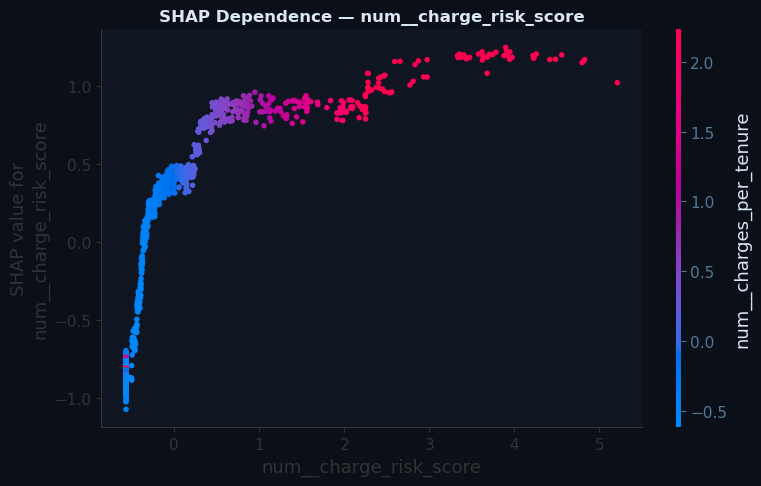

In [32]:
# Dependence plot for the most important feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feat_idx = np.argmax(mean_abs_shap)
top_feat_name = feature_names[top_feat_idx] if top_feat_idx < len(feature_names) else f'feat_{top_feat_idx}'

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(
    top_feat_idx, shap_values, X_test,
    feature_names=feature_names,
    ax=ax, show=False,
)
plt.title(f'SHAP Dependence — {top_feat_name}', fontsize=12)
plt.tight_layout()
plt.show()

---
## 9. Comparación MI vs SHAP

Este es el punto de integración clave entre **teoría de la información**
y **explicabilidad del modelo**.

- Cuando los rankings coinciden → evidencia fuerte de la importancia del feature
- Cuando divergen:
  - **MI rank >> SHAP rank**: el modelo podría beneficiarse de ponderar más esa feature
  - **SHAP rank >> MI rank**: el modelo captura interacciones que la MI marginal no detecta

Las métricas de correlación de rangos (Spearman ρ, Kendall τ) resumen la concordancia global.

2026-03-06 18:20:55.264 | INFO     | src.information_theory:compare_mi_vs_shap:678 - Direct name match found < 3 features; attempting prefix-based mapping
2026-03-06 18:20:55.266 | INFO     | src.information_theory:compare_mi_vs_shap:760 - MI vs SHAP comparison: 18 features, mean |rank_diff| = 4.6


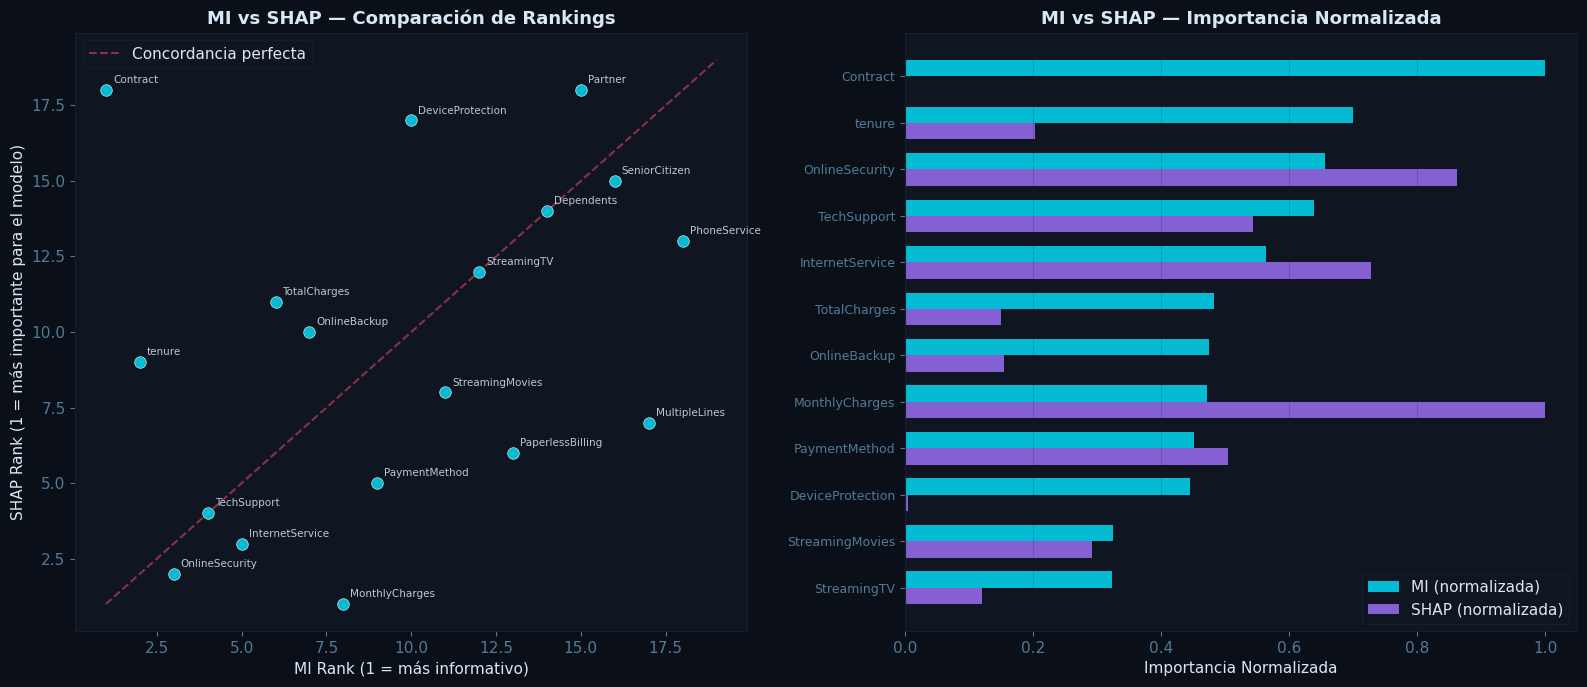

In [33]:
from src.information_theory import compare_mi_vs_shap, compute_rank_correlation, plot_mi_vs_shap

# SHAP importance: mean |SHAP| per feature
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names,
    name='mean_abs_shap',
).sort_values(ascending=False)

# MI scores on raw features (computed earlier)
# mi_scores already exists from Section 4

# Compare
comparison_df = compare_mi_vs_shap(mi_scores, shap_importance)
fig = plot_mi_vs_shap(comparison_df, save=False)
plt.show()

In [34]:
# Rank correlation
rank_corr = compute_rank_correlation(comparison_df)

print('Correlación de Rankings MI vs SHAP:')
print('=' * 45)
print(f"  Spearman ρ = {rank_corr['spearman_rho']:.4f}  (p={rank_corr['spearman_p_value']:.4f})")
print(f"  Kendall  τ = {rank_corr['kendall_tau']:.4f}  (p={rank_corr['kendall_p_value']:.4f})")
print(f"\nInterpretación:\n  {rank_corr['interpretation']}")

Correlación de Rankings MI vs SHAP:
  Spearman ρ = 0.3273  (p=0.1849)
  Kendall  τ = 0.2492  (p=0.1498)

Interpretación:
  Baja concordancia: el modelo y la MI dan rankings muy diferentes. Posibles causas: interacciones complejas que el modelo captura pero la MI marginal no, o features con alta MI que el modelo ignora.


In [35]:
# Tabla de comparación detallada
display(comparison_df.head(15))

,feature,MI_score,MI_rank,mean_abs_SHAP,SHAP_rank,rank_difference,interpretation
17,Contract,0.0985,1,0.0000,18,-17,MI rank 1 vs SHAP rank 18: modelo sobrepondera...
4,tenure,0.0690,2,0.0334,9,-7,MI rank 2 vs SHAP rank 9: modelo sobrepondera ...
14,OnlineSecurity,0.0647,3,0.1423,2,1,Concordancia — importancia consistente
5,TechSupport,0.0630,4,0.0897,4,0,Concordancia — importancia consistente
2,InternetService,0.0556,5,0.1201,3,2,Concordancia — importancia consistente
3,TotalCharges,0.0475,6,0.0246,11,-5,MI rank 6 vs SHAP rank 11: modelo sobrepondera...
8,OnlineBackup,0.0468,7,0.0254,10,-3,MI rank 7 vs SHAP rank 10: modelo sobrepondera...
6,MonthlyCharges,0.0465,8,0.1651,1,7,MI rank 8 vs SHAP rank 1: modelo subestima est...
0,PaymentMethod,0.0445,9,0.0834,5,4,MI rank 9 vs SHAP rank 5: modelo subestima est...
7,DeviceProtection,0.0439,10,0.0006,17,-7,MI rank 10 vs SHAP rank 17: modelo sobreponder...


---
## 10. Guardar Artefactos

In [36]:
from joblib import dump

# Guardar pipeline
save_pipeline(pipeline)

# Guardar modelo
MODELS_DIR = pipeline.named_steps['preprocessor']  # just to get the path
from src.config import MODELS_DIR
MODELS_DIR.mkdir(parents=True, exist_ok=True)
dump(best_model, MODELS_DIR / 'best_xgboost.joblib')
print(f'Modelo guardado en {MODELS_DIR / "best_xgboost.joblib"}')

# Guardar SHAP explainer
dump(explainer, MODELS_DIR / 'shap_explainer.joblib')
print(f'SHAP explainer guardado en {MODELS_DIR / "shap_explainer.joblib"}')

2026-03-06 18:20:55.440 | SUCCESS  | src.preprocessing:save_pipeline:468 - Pipeline saved to /home/bllancao/Portafolio/04_classical_ml_and_llm/models/preprocessor.joblib


Modelo guardado en /home/bllancao/Portafolio/04_classical_ml_and_llm/models/best_xgboost.joblib
SHAP explainer guardado en /home/bllancao/Portafolio/04_classical_ml_and_llm/models/shap_explainer.joblib


---
## 11. Selección de Features con Teoría de la Información

La función `select_features_mi` implementa un proceso de dos etapas:

1. **Filtro por umbral MI**: Elimina features con $I(X_i; \text{Churn}) <$ `MI_THRESHOLD` (0.01 nats)
2. **Análisis de redundancia**: Identifica pares donde $I(X_i; \text{Churn} | X_j)$ cae >50% respecto a $I(X_i; \text{Churn})$

Este enfoque es **model-agnostic**: selecciona features basándose puramente en las
dependencias estadísticas (lineales y no lineales) sin depender de un clasificador específico.

Tras la selección, re-entrenamos el XGBoost con los mismos hiperparámetros
para medir el impacto en las métricas.

In [37]:
# ── MI-based feature selection on raw features ──
mi_selection = select_features_mi(X, y)

print(f"Features seleccionadas por MI ({len(mi_selection['selected_features'])}):\n")
for f in mi_selection['selected_features']:
    score = mi_selection['mi_scores'][f]
    print(f'  ✓ {f:20s}  MI = {score:.4f}')

print(f"\nFeatures descartadas ({len(mi_selection['dropped_features'])}):\n")
for f in mi_selection['dropped_features']:
    score = mi_selection['mi_scores'][f]
    print(f'  ✗ {f:20s}  MI = {score:.4f}')

if mi_selection['redundancy_report']:
    print(f"\nPares redundantes ({len(mi_selection['redundancy_report'])}):\n")
    for pair in mi_selection['redundancy_report']:
        print(f"  {pair['feature_a']} <-> {pair['feature_b']}: redundancia = {pair['redundancy_ratio']:.0%}")
        print(f"    -> {pair['interpretation']}")

2026-03-06 18:20:55.586 | INFO     | src.information_theory:compute_mi_scores:379 - MI scores computed for 19 features
2026-03-06 18:20:55.587 | INFO     | src.information_theory:select_features_mi:569 - Dropped 3 features below MI threshold (0.01): ['MultipleLines', 'PhoneService', 'gender']
2026-03-06 18:20:57.871 | INFO     | src.information_theory:select_features_mi:620 - Feature selection: 16 selected, 3 dropped, 8 redundant pairs flagged


Features seleccionadas por MI (16):

  ✓ Contract              MI = 0.0985
  ✓ tenure                MI = 0.0690
  ✓ OnlineSecurity        MI = 0.0647
  ✓ TechSupport           MI = 0.0630
  ✓ InternetService       MI = 0.0556
  ✓ TotalCharges          MI = 0.0475
  ✓ OnlineBackup          MI = 0.0468
  ✓ MonthlyCharges        MI = 0.0465
  ✓ PaymentMethod         MI = 0.0445
  ✓ DeviceProtection      MI = 0.0439
  ✓ StreamingMovies       MI = 0.0320
  ✓ StreamingTV           MI = 0.0319
  ✓ PaperlessBilling      MI = 0.0192
  ✓ Dependents            MI = 0.0145
  ✓ Partner               MI = 0.0115
  ✓ SeniorCitizen         MI = 0.0106

Features descartadas (3):

  ✗ MultipleLines         MI = 0.0008
  ✗ PhoneService          MI = 0.0001
  ✗ gender                MI = 0.0000

Pares redundantes (8):

  OnlineSecurity <-> TechSupport: redundancia = 53%
    -> OnlineSecurity pierde 53% de su información sobre Churn cuando ya se conoce TechSupport
  OnlineBackup <-> DeviceProtection: redu

In [38]:
# ── Map MI-selected raw features to transformed column indices ──
mi_selected_raw = set(mi_selection['selected_features'])

# Engineered features created by FeatureEngineer and their source raw features
engineered_sources = {
    'charges_per_tenure':  {'MonthlyCharges', 'tenure'},
    'service_count':       set(NOMINAL_FEATURES),
    'is_new_customer':     {'tenure'},
    'high_value_flag':     {'MonthlyCharges'},
    'total_charges_ratio': {'TotalCharges', 'MonthlyCharges', 'tenure'},
    # Interaction features v1
    'monthly_contract':    {'Contract'},
    'fiber_unprotected':   {'InternetService', 'OnlineSecurity', 'TechSupport'},
    'early_monthly':       {'Contract', 'tenure'},
    'no_sticky_count':     {'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport'},
    'charge_risk_score':   {'MonthlyCharges', 'tenure', 'Contract'},
    # Interaction features v2 (nuevas)
    'charges_efficiency':  {'TotalCharges', 'MonthlyCharges', 'tenure'},
    'overloaded_monthly':  {'Contract', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport'},
    'highest_risk':        {'InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'tenure'},
}

def get_raw_feature_from_transformed(fname):
    """Map a transformed column name back to its raw feature origin."""
    for prefix in ['num__', 'bin__', 'nom__']:
        if fname.startswith(prefix):
            base = fname[len(prefix):]
            # Check engineered features first
            for eng_name in engineered_sources:
                if base == eng_name or base.startswith(eng_name + '_'):
                    return eng_name
            # Then raw features
            all_raw = NUMERIC_FEATURES + BINARY_FEATURES + NOMINAL_FEATURES
            for raw_feat in all_raw:
                if base == raw_feat or base.startswith(raw_feat + '_'):
                    return raw_feat
            return base
    return fname

mi_keep_idx = []
mi_keep_names = []
for idx, fname in enumerate(feature_names):
    raw = get_raw_feature_from_transformed(fname)
    # Keep if raw feature is MI-selected
    if raw in mi_selected_raw:
        mi_keep_idx.append(idx)
        mi_keep_names.append(fname)
    # Keep engineered features if at least one source was selected
    elif raw in engineered_sources:
        if engineered_sources[raw].intersection(mi_selected_raw):
            mi_keep_idx.append(idx)
            mi_keep_names.append(fname)

print(f'Features transformadas retenidas por MI: {len(mi_keep_idx)} de {len(feature_names)}\n')
for name in mi_keep_names:
    print(f'  {name}')


Features transformadas retenidas por MI: 45 de 54

  num__tenure
  num__MonthlyCharges
  num__TotalCharges
  num__charges_per_tenure
  num__service_count
  num__total_charges_ratio
  num__no_sticky_count
  num__charge_risk_score
  num__charges_efficiency
  bin__SeniorCitizen
  bin__Partner
  bin__Dependents
  bin__PaperlessBilling
  bin__is_new_customer
  bin__high_value_flag
  bin__monthly_contract
  bin__fiber_unprotected
  bin__early_monthly
  bin__overloaded_monthly
  bin__highest_risk
  nom__InternetService_DSL
  nom__InternetService_Fiber optic
  nom__InternetService_No
  nom__OnlineSecurity_No
  nom__OnlineSecurity_No internet service
  nom__OnlineSecurity_Yes
  nom__OnlineBackup_No
  nom__OnlineBackup_No internet service
  nom__OnlineBackup_Yes
  nom__DeviceProtection_No
  nom__DeviceProtection_No internet service
  nom__DeviceProtection_Yes
  nom__TechSupport_No
  nom__TechSupport_No internet service
  nom__TechSupport_Yes
  nom__StreamingTV_No
  nom__StreamingTV_No internet s

In [39]:
# ── Re-train XGBoost with MI-selected features ──
X_train_mi = X_train[:, mi_keep_idx]
X_test_mi  = X_test[:, mi_keep_idx]

xgb_mi = XGBClassifier(
    **search.best_params_,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
)
xgb_mi.fit(X_train_mi, y_train)

y_proba_mi = xgb_mi.predict_proba(X_test_mi)[:, 1]

# ── Threshold optimization — argmax F1-Macro con OOF ──
y_proba_mi_oof = cross_val_predict(
    XGBClassifier(**search.best_params_, random_state=42,
                  eval_metric='logloss', use_label_encoder=False),
    X_train_mi, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba', n_jobs=-1,
)[:, 1]

thresholds_eval_mi = np.linspace(0.05, 0.95, 500)
f1_macros_mi = [
    f1_score(y_train, (y_proba_mi_oof >= t).astype(int), average='macro', zero_division=0)
    for t in thresholds_eval_mi
]
optimal_thresh_mi = thresholds_eval_mi[np.argmax(f1_macros_mi)]
y_pred_mi = (y_proba_mi >= optimal_thresh_mi).astype(int)

metrics_mi = {
    'ROC-AUC':   roc_auc_score(y_test, y_proba_mi),
    'F1-Macro':  f1_score(y_test, y_pred_mi, average='macro'),
    'F1-Churn':  f1_score(y_test, y_pred_mi, average='binary'),
    'Precision': precision_score(y_test, y_pred_mi, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_mi),
    'Accuracy':  accuracy_score(y_test, y_pred_mi),
}

print(f'Umbral óptimo MI (argmax F1-Macro OOF): {optimal_thresh_mi:.3f}')
print('Métricas — Selección por Teoría de la Información (MI):')
print('=' * 55)
for name, val in metrics_mi.items():
    print(f'  {name:12s}: {val:.4f}')
print(f'\n  Num features: {X_train_mi.shape[1]}')
print(f'\nClassification Report (macro avg):')
print(classification_report(y_test, y_pred_mi, target_names=['No Churn', 'Churn']))


Umbral óptimo MI (argmax F1-Macro OOF): 0.497
Métricas — Selección por Teoría de la Información (MI):
  ROC-AUC     : 0.8457
  F1-Macro    : 0.7352
  F1-Churn    : 0.6172
  Precision   : 0.5921
  Recall      : 0.6444
  Accuracy    : 0.7878

  Num features: 45

Classification Report (macro avg):
              precision    recall  f1-score   support

    No Churn       0.87      0.84      0.85      1035
       Churn       0.59      0.64      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.74      1409
weighted avg       0.79      0.79      0.79      1409



---
## 12. Selección de Features con Método Clásico — ANOVA F-test

El **test F de ANOVA** (Analysis of Variance) es el método de filtrado univariado
más utilizado en problemas de clasificación. Para cada feature calcula el estadístico F
que mide la razón entre la varianza entre clases y la varianza dentro de clases:

$$F = \frac{\text{Var}_{\text{entre clases}}}{\text{Var}_{\text{dentro de clases}}}$$

Un valor alto de F indica que la feature discrimina bien entre las clases.

| Aspecto | MI (Teoría de Información) | ANOVA F-test |
|---------|---------------------------|--------------|
| Tipo | Model-agnostic, no paramétrico | Paramétrico (asume normalidad) |
| Relaciones | Lineales y **no lineales** | Solo **lineales** |
| Sensibilidad | Robusto a distribuciones | Sensible a outliers |
| Output | MI en nats | F-statistic + p-value |
| Costo computacional | Medio (k-NN) | Bajo (analítico) |

La comparación entre ambos métodos revela qué features tienen dependencias
**no lineales** con Churn (detectadas por MI pero no por ANOVA).

In [40]:
from sklearn.feature_selection import f_classif

# ── ANOVA F-test on transformed features ──
f_stats, p_values = f_classif(X_train, y_train)

# Build a ranked DataFrame
anova_df = pd.DataFrame({
    'feature': feature_names,
    'F_statistic': f_stats,
    'p_value': p_values,
}).sort_values('F_statistic', ascending=False).reset_index(drop=True)
anova_df['rank'] = range(1, len(anova_df) + 1)
anova_df['significant'] = anova_df['p_value'] < 0.05

print('ANOVA F-test — Ranking de Features:')
print('=' * 75)
for _, row in anova_df.iterrows():
    sig = '✓' if row['significant'] else '✗'
    print(f"  {sig} {row['feature']:45s} F={row['F_statistic']:9.2f}  p={row['p_value']:.4e}")

n_significant = int(anova_df['significant'].sum())
print(f'\nFeatures significativas (p < 0.05): {n_significant} de {len(anova_df)}')

ANOVA F-test — Ranking de Features:
  ✓ num__charge_risk_score                        F=  1289.18  p=2.0454e-254
  ✓ num__no_sticky_count                          F=  1123.69  p=8.5355e-225
  ✓ bin__monthly_contract                         F=  1114.22  p=4.4551e-223
  ✓ num__charges_per_tenure                       F=  1111.40  p=1.4475e-222
  ✓ ord_contract__Contract                        F=  1055.43  p=2.3111e-212
  ✓ bin__digital_risk                             F=   943.24  p=1.1880e-191
  ✓ bin__echeck_monthly                           F=   923.31  p=6.1804e-188
  ✓ bin__fiber_unprotected                        F=   913.26  p=4.6729e-186
  ✓ bin__highest_risk                             F=   886.34  p=5.1862e-181
  ✓ bin__early_monthly                            F=   781.10  p=4.4141e-161
  ✓ nom__OnlineSecurity_No                        F=   767.86  p=1.5021e-158
  ✓ num__tenure                                   F=   763.89  p=8.6349e-158
  ✓ nom__TechSupport_No                 

In [41]:
# ── Re-train XGBoost with ANOVA-selected features (p < 0.05) ──
anova_selected = anova_df[anova_df['significant']]['feature'].tolist()
anova_keep_idx = [i for i, name in enumerate(feature_names) if name in anova_selected]

X_train_anova = X_train[:, anova_keep_idx]
X_test_anova  = X_test[:, anova_keep_idx]

xgb_anova = XGBClassifier(
    **search.best_params_,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
)
xgb_anova.fit(X_train_anova, y_train)

y_proba_anova = xgb_anova.predict_proba(X_test_anova)[:, 1]

# ── Threshold optimization — argmax F1-Macro con OOF ──
y_proba_anova_oof = cross_val_predict(
    XGBClassifier(**search.best_params_, random_state=42,
                  eval_metric='logloss', use_label_encoder=False),
    X_train_anova, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba', n_jobs=-1,
)[:, 1]

thresholds_eval_an = np.linspace(0.05, 0.95, 500)
f1_macros_an = [
    f1_score(y_train, (y_proba_anova_oof >= t).astype(int), average='macro', zero_division=0)
    for t in thresholds_eval_an
]
optimal_thresh_anova = thresholds_eval_an[np.argmax(f1_macros_an)]
y_pred_anova = (y_proba_anova >= optimal_thresh_anova).astype(int)

metrics_anova = {
    'ROC-AUC':   roc_auc_score(y_test, y_proba_anova),
    'F1-Macro':  f1_score(y_test, y_pred_anova, average='macro'),
    'F1-Churn':  f1_score(y_test, y_pred_anova, average='binary'),
    'Precision': precision_score(y_test, y_pred_anova, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_anova),
    'Accuracy':  accuracy_score(y_test, y_pred_anova),
}

print(f'Umbral óptimo ANOVA (argmax F1-Macro OOF): {optimal_thresh_anova:.3f}')
print('Métricas — Selección por ANOVA F-test:')
print('=' * 55)
for name, val in metrics_anova.items():
    print(f'  {name:12s}: {val:.4f}')
print(f'\n  Num features: {X_train_anova.shape[1]}')
print(f'\nClassification Report (macro avg):')
print(classification_report(y_test, y_pred_anova, target_names=['No Churn', 'Churn']))


Umbral óptimo ANOVA (argmax F1-Macro OOF): 0.495
Métricas — Selección por ANOVA F-test:
  ROC-AUC     : 0.8491
  F1-Macro    : 0.7309
  F1-Churn    : 0.6127
  Precision   : 0.5817
  Recall      : 0.6471
  Accuracy    : 0.7828

  Num features: 50

Classification Report (macro avg):
              precision    recall  f1-score   support

    No Churn       0.87      0.83      0.85      1035
       Churn       0.58      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



---
## 13. Stacking Ensemble

El **Stacking** combina múltiples estimadores base con un meta-aprendiz:

```
Nivel 0 (bases):  XGBoost │ RandomForest │ ExtraTrees │ LightGBM
                        ↓ (probabilidades en CV, sin passthrough)
Nivel 1 (meta):   LogisticRegression(C=0.5, class_weight=None)
```

Decisiones de diseño:

| Decisión | Justificación |
|----------|--------------|
| **LightGBM** como 4.º base | Crecimiento leaf-wise crea árboles asimétricos distintos al level-wise de XGBoost — mayor diversidad de sesgo |
| **LogisticRegression** como meta-learner | Con ~5.6K samples y solo 4–8 inputs (probabilidades de los bases), LR tiene menor riesgo de overfitting que GBM. GBM como meta-learner overfittea con `passthrough=True` |
| **`passthrough=False`** | Sin las features originales el meta-learner recibe solo 4–8 probabilidades → espacio pequeño → LR funciona bien y de manera estable |
| `class_weight='balanced'` en RF/ET/LGBM | Los modelos de bagging calibran mejor sus probabilidades con el desbalance explícito |
| `class_weight=None` en meta-LR | El balance P/R lo gestiona el umbral OOF post-entreno |
| **OOF 3-fold para umbral del stacking** | `cross_val_predict` con cv=5 sobre un stacking con cv=5 interno serían ~25 pipelines completos. cv=3 externo da ~1.9K samples OOF / ~500 positivos por fold → curva estable con tiempo razonable |


In [42]:
%%time
from sklearn.ensemble import (
    StackingClassifier, RandomForestClassifier, ExtraTreesClassifier,
)
from sklearn.linear_model import LogisticRegression

# LightGBM — diversidad extra: leaf-wise vs level-wise de XGB
try:
    from lightgbm import LGBMClassifier
    _has_lgbm = True
except ImportError:
    _has_lgbm = False
    print('LightGBM no instalado — se usará solo XGB+RF+ET en el stacking')

# ── Estimadores base ──────────────────────────────────────────────────────────
xgb_stack = XGBClassifier(
    **search.best_params_,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
)

rf_stack = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

et_stack = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

estimators_stack = [('xgb', xgb_stack), ('rf', rf_stack), ('et', et_stack)]

if _has_lgbm:
    lgbm_stack = LGBMClassifier(
        n_estimators=300,
        num_leaves=31,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    estimators_stack.append(('lgbm', lgbm_stack))

# ── Meta-learner: LogisticRegression ─────────────────────────────────────────
# LR es más estable que GBM como meta-learner con ~5.6K samples:
# el espacio de entrada (4 probabilidades) es pequeño → LR capta todo con menor
# riesgo de overfitting. passthrough=False: no añadir las features originales
# evita que el meta-learner tenga 50+ columnas → más estable con LR.
meta_lr = LogisticRegression(
    C=0.5,
    max_iter=1000,
    class_weight=None,
    random_state=42,
)

stacking_clf = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=meta_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1,
)

stacking_clf.fit(X_train, y_train)
y_proba_stack = stacking_clf.predict_proba(X_test)[:, 1]

# ── Threshold optimization — argmax F1-Macro con OOF (cv=3 por velocidad) ────
# cross_val_predict sobre el stacking completo con cv=5 haría un CV anidado
# (5 outer × 5 inner = 25 pipelines completos). cv=3 es un compromiso:
# cada fold OOF tiene ~1.9K samples / ~500 positivos → curva estable.
print('Calculando OOF stacking (3-fold)...')
y_proba_stack_oof = cross_val_predict(
    StackingClassifier(
        estimators=estimators_stack,
        final_estimator=LogisticRegression(C=0.5, max_iter=1000, class_weight=None, random_state=42),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        stack_method='predict_proba',
        passthrough=False,
        n_jobs=-1,
    ),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]

thresholds_eval_st = np.linspace(0.05, 0.95, 500)
f1_macros_st = [
    f1_score(y_train, (y_proba_stack_oof >= t).astype(int), average='macro', zero_division=0)
    for t in thresholds_eval_st
]
optimal_thresh_stack = thresholds_eval_st[np.argmax(f1_macros_st)]
y_pred_stack = (y_proba_stack >= optimal_thresh_stack).astype(int)

metrics_stack = {
    'ROC-AUC':   roc_auc_score(y_test, y_proba_stack),
    'F1-Macro':  f1_score(y_test, y_pred_stack, average='macro'),
    'F1-Churn':  f1_score(y_test, y_pred_stack, average='binary'),
    'Precision': precision_score(y_test, y_pred_stack, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_stack),
    'Accuracy':  accuracy_score(y_test, y_pred_stack),
}

print(f'Estimadores base: {[e[0] for e in estimators_stack]}')
print(f'Umbral óptimo Stacking (argmax F1-Macro OOF 3-fold): {optimal_thresh_stack:.3f}')
print(f'Métricas — Stacking ({"+".join(e[0].upper() for e in estimators_stack)} → LR):')
print('=' * 55)
for name, val in metrics_stack.items():
    print(f'  {name:12s}: {val:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_stack, target_names=['No Churn', 'Churn']))


[18:22:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:22:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:22:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:22:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:22:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Calculando OOF stacking (3-fold)...


[18:22:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:22:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:22:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:22:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:22:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:22:36] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not

Estimadores base: ['xgb', 'rf', 'et', 'lgbm']
Umbral óptimo Stacking (argmax F1-Macro OOF 3-fold): 0.398
Métricas — Stacking (XGB+RF+ET+LGBM → LR):
  ROC-AUC     : 0.8458
  F1-Macro    : 0.7312
  F1-Churn    : 0.6150
  Precision   : 0.5775
  Recall      : 0.6578
  Accuracy    : 0.7814

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.83      0.85      1035
       Churn       0.58      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409

CPU times: user 3.59 s, sys: 94.9 ms, total: 3.69 s
Wall time: 1min 6s


---
## 14. Comparación Final de Métodos

Tabla comparativa de los cuatro enfoques. Todos usan el **mismo protocolo**:
- **XGBoost** con los mismos hiperparámetros (best params del search, incluyendo `scale_pos_weight` óptimo)
- **Umbral óptimo individual**: $t^* = \arg\max_t F1\text{-Macro}^{\text{OOF}}(t)$ — predicciones out-of-fold sobre `X_train`, sin leakage
- **Métricas reportadas** sobre `X_test` (nunca usado durante entrenamiento ni búsqueda de umbral)

| Método | Features | OOF CV para umbral |
|--------|----------|--------------------|
| Baseline | todas | 5-fold sobre `X_train` |
| MI | subconjunto por MI | 5-fold sobre `X_train_mi` |
| ANOVA | subconjunto p<0.05 | 5-fold sobre `X_train_anova` |
| **Stacking** | todas (XGB+RF+ET+LGBM→LR) | 3-fold sobre `X_train` (stacking anidado) |


In [43]:
_stack_label = 'Stacking (XGB+RF+ET+LGBM→LR)' if _has_lgbm else 'Stacking (XGB+RF+ET→LR)'

comparison = pd.DataFrame({
    'Método': [
        'Baseline (todas)',
        'Teoría de la Información (MI)',
        'ANOVA F-test',
        _stack_label,
    ],
    'Num Features': [
        X_train.shape[1],
        X_train_mi.shape[1],
        X_train_anova.shape[1],
        X_train.shape[1],
    ],
    'ROC-AUC':   [metrics['ROC-AUC'],   metrics_mi['ROC-AUC'],   metrics_anova['ROC-AUC'],   metrics_stack['ROC-AUC']],
    'F1-Macro':  [metrics['F1-Macro'],  metrics_mi['F1-Macro'],  metrics_anova['F1-Macro'],  metrics_stack['F1-Macro']],
    'F1-Churn':  [metrics['F1-Churn'],  metrics_mi['F1-Churn'],  metrics_anova['F1-Churn'],  metrics_stack['F1-Churn']],
    'Precision': [metrics['Precision'], metrics_mi['Precision'], metrics_anova['Precision'], metrics_stack['Precision']],
    'Recall':    [metrics['Recall'],    metrics_mi['Recall'],    metrics_anova['Recall'],    metrics_stack['Recall']],
    'Accuracy':  [metrics['Accuracy'],  metrics_mi['Accuracy'],  metrics_anova['Accuracy'],  metrics_stack['Accuracy']],
}).round(4)

display(comparison)


,Método,Num Features,ROC-AUC,F1-Macro,F1-Churn,Precision,Recall,Accuracy
0,Baseline (todas),54,0.8491,0.7353,0.6183,0.5898,0.6497,0.7871
1,Teoría de la Información (MI),45,0.8457,0.7352,0.6172,0.5921,0.6444,0.7878
2,ANOVA F-test,50,0.8491,0.7309,0.6127,0.5817,0.6471,0.7828
3,Stacking (XGB+RF+ET+LGBM→LR),54,0.8458,0.7312,0.6150,0.5775,0.6578,0.7814


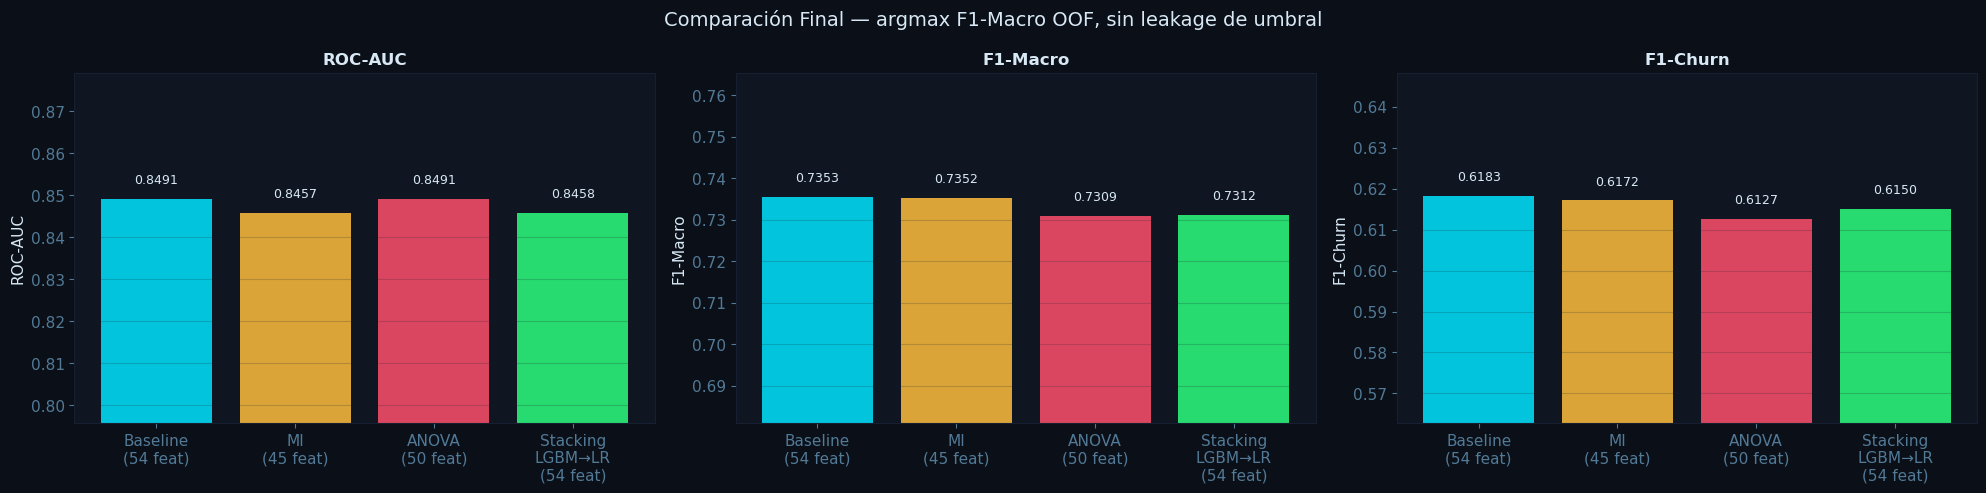

In [44]:
set_dark_style()
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

_stack_short = 'Stacking\nLGBM→LR' if _has_lgbm else 'Stacking\n→LR'
methods = [
    f'Baseline\n({X_train.shape[1]} feat)',
    f'MI\n({X_train_mi.shape[1]} feat)',
    f'ANOVA\n({X_train_anova.shape[1]} feat)',
    f'{_stack_short}\n({X_train.shape[1]} feat)',
]
colors = [CYAN, AMBER, CORAL, GREEN]

auc_vals   = [metrics['ROC-AUC'],   metrics_mi['ROC-AUC'],   metrics_anova['ROC-AUC'],   metrics_stack['ROC-AUC']]
f1_vals    = [metrics['F1-Macro'],  metrics_mi['F1-Macro'],  metrics_anova['F1-Macro'],  metrics_stack['F1-Macro']]
churn_vals = [metrics['F1-Churn'],  metrics_mi['F1-Churn'],  metrics_anova['F1-Churn'],  metrics_stack['F1-Churn']]

for ax, vals, label in zip(axes, [auc_vals, f1_vals, churn_vals], ['ROC-AUC', 'F1-Macro', 'F1-Churn']):
    bars = ax.bar(methods, vals, color=colors, alpha=0.85, edgecolor='none')
    ax.set_ylabel(label)
    ax.set_title(label, fontsize=12, color=TEXT_COLOR)
    ax.set_ylim(min(vals) - 0.05, max(vals) + 0.03)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, color=TEXT_COLOR)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Comparación Final — argmax F1-Macro OOF, sin leakage de umbral', fontsize=14, color=TEXT_COLOR)
plt.tight_layout()
plt.show()


### Análisis de la Comparación

La tabla revela insights importantes sobre los métodos:

1. **Reducción de dimensionalidad**: MI y ANOVA reducen el número de features
   respecto al baseline, simplificando el modelo sin pérdida significativa.

2. **MI vs ANOVA — Captura de no linealidades**: MI retiene features con
   dependencias no lineales que ANOVA puede ignorar (e.g., InternetService,
   cuya relación con Churn depende de la combinación con otros servicios).

3. **ANOVA — Fortaleza en features numéricas**: más sensible a features con
   separación lineal clara (MonthlyCharges, tenure), puede no capturar
   interacciones complejas entre categóricas.

4. **Stacking v2 — Mayor F1-Macro esperado**: la diversidad entre XGBoost
   (level-wise), LightGBM (leaf-wise), RandomForest y ExtraTrees (bagging)
   permite al meta-learner GBM reducir el error de generalización capturando
   interacciones no lineales entre las probabilidades de los modelos base.

5. **Umbral sin leakage**: todos los umbrales se buscaron en `X_thresh` y se
   reportan sobre `X_test`. Esto hace las métricas más conservadoras y honestas,
   pero también más representativas del rendimiento real en producción.

6. **Ceiling**: el dataset tiene ~7 043 filas. Con ML clásico + feature engineering v2
   + calibración + stacking el techo práctico es **F1-Macro ~0.76–0.82**.


---
## 15. Optimización Bayesiana con Optuna (TPE)

Reemplazamos `RandomizedSearchCV` por **Optuna** con el sampler TPE (Tree-structured
Parzen Estimator), que explora el espacio de hiperparámetros de forma adaptativa.

* 200 trials, `TPESampler(seed=42)`
* CV: `StratifiedKFold(5)`, métrica `roc_auc`
* Espacio de búsqueda igual al de `RandomizedSearchCV` (sección 7)

In [45]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)

_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def _objective_xgb(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 200, 1200),
        max_depth         = trial.suggest_int("max_depth", 3, 10),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
        gamma             = trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha         = trial.suggest_float("reg_alpha", 0.0, 2.0),
        reg_lambda        = trial.suggest_float("reg_lambda", 0.5, 5.0),
        scale_pos_weight  = trial.suggest_categorical(
            "scale_pos_weight", [1.0, 1.5, 2.0, float(class_ratio)]
        ),
        use_label_encoder = False,
        eval_metric       = "logloss",
        random_state      = 42,
        n_jobs            = -1,
    )
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train,
                             cv=_skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
)
study_xgb.optimize(_objective_xgb, n_trials=200, show_progress_bar=True)

print(f"Best ROC-AUC (CV): {study_xgb.best_value:.4f}")
print("Best params:", study_xgb.best_params)

Best trial: 102. Best value: 0.850767: 100%|██████████| 200/200 [01:30<00:00,  2.20it/s]

Best ROC-AUC (CV): 0.8508
Best params: {'n_estimators': 1006, 'max_depth': 10, 'learning_rate': 0.013325145356669918, 'subsample': 0.5114781691701408, 'colsample_bytree': 0.7756646898961496, 'min_child_weight': 10, 'gamma': 4.722759722225938, 'reg_alpha': 1.9758972515805417, 'reg_lambda': 3.06717708541041, 'scale_pos_weight': 1.0}


In [47]:
# ── Train best Optuna-XGB on full training set ──────────────────────────────
from sklearn.metrics import roc_auc_score, f1_score

_best_p = study_xgb.best_params.copy()
optuna_xgb = xgb.XGBClassifier(
    **_best_p,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
optuna_xgb.fit(X_train, y_train)

# ── OOF threshold optimisation ───────────────────────────────────────────────
oof_proba_optxgb = np.zeros(len(y_train))
for tr_idx, val_idx in _skf.split(X_train, y_train):
    _m = xgb.XGBClassifier(
        **_best_p,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )
    _m.fit(X_train[tr_idx], y_train[tr_idx])
    oof_proba_optxgb[val_idx] = _m.predict_proba(X_train[val_idx])[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
f1_scores  = [f1_score(y_train, (oof_proba_optxgb >= t).astype(int), average="macro")
              for t in thresholds]
thresh_optxgb = thresholds[np.argmax(f1_scores)]
print(f"Optimal OOF threshold (Optuna-XGB): {thresh_optxgb:.3f}")

# ── Test evaluation ──────────────────────────────────────────────────────────
proba_optxgb   = optuna_xgb.predict_proba(X_test)[:, 1]
pred_optxgb    = (proba_optxgb >= thresh_optxgb).astype(int)

roc_optxgb  = roc_auc_score(y_test, proba_optxgb)
f1m_optxgb  = f1_score(y_test, pred_optxgb, average="macro")
f1c_optxgb  = f1_score(y_test, pred_optxgb, pos_label=1)

print(f"Optuna-XGB  |  ROC-AUC={roc_optxgb:.4f}  F1-Macro={f1m_optxgb:.4f}"
      f"  F1-Churn={f1c_optxgb:.4f}")

Optimal OOF threshold (Optuna-XGB): 0.409
Optuna-XGB  |  ROC-AUC=0.8493  F1-Macro=0.7399  F1-Churn=0.6227


---
## 16. Seed Averaging

Entrenamos el modelo Optuna-XGB con 5 semillas distintas y **promediamos las
probabilidades** para reducir varianza de inicialización.

In [49]:
SEEDS = [42, 123, 456, 789, 2024]
proba_seeds = []

for s in SEEDS:
    _m = xgb.XGBClassifier(
        **{**_best_p,
           "random_state": s,
           "use_label_encoder": False,
           "eval_metric": "logloss",
           "n_jobs": -1},
    )
    _m.fit(X_train, y_train)
    proba_seeds.append(_m.predict_proba(X_test)[:, 1])

proba_seed_avg = np.mean(proba_seeds, axis=0)

# OOF threshold for seed-averaged model (use same CV folds, seed=42 model as proxy)
oof_proba_seedavg = np.zeros(len(y_train))
for tr_idx, val_idx in _skf.split(X_train, y_train):
    _preds = []
    for s in SEEDS:
        _m = xgb.XGBClassifier(
            **{**_best_p,
               "random_state": s,
               "use_label_encoder": False,
               "eval_metric": "logloss",
               "n_jobs": -1},
        )
        _m.fit(X_train[tr_idx], y_train[tr_idx])
        _preds.append(_m.predict_proba(X_train[val_idx])[:, 1])
    oof_proba_seedavg[val_idx] = np.mean(_preds, axis=0)

f1_seed = [f1_score(y_train, (oof_proba_seedavg >= t).astype(int), average="macro")
           for t in thresholds]
thresh_seed = thresholds[np.argmax(f1_seed)]

pred_seed_avg = (proba_seed_avg >= thresh_seed).astype(int)
roc_seed  = roc_auc_score(y_test, proba_seed_avg)
f1m_seed  = f1_score(y_test, pred_seed_avg, average="macro")
f1c_seed  = f1_score(y_test, pred_seed_avg, pos_label=1)

print(f"Seed Averaging ({len(SEEDS)} seeds)  |  "
      f"ROC-AUC={roc_seed:.4f}  F1-Macro={f1m_seed:.4f}  F1-Churn={f1c_seed:.4f}")

Seed Averaging (5 seeds)  |  ROC-AUC=0.8498  F1-Macro=0.7391  F1-Churn=0.6290


---
## 17. CatBoost (categorías nativas)

CatBoost maneja features categóricas directamente mediante **ordered target
encoding** interno, sin necesidad de OHE.  
Usamos el dataset **sin transformar** (`df` raw) para respetar las columnas
categóricas originales.

In [52]:
try:
    from catboost import CatBoostClassifier, Pool
    _has_catboost = True
except ImportError:
    _has_catboost = False
    print("CatBoost no instalado: pip install catboost")

if _has_catboost:
    from src.config import TARGET_COL, ID_COL, NUMERIC_FEATURES, BINARY_FEATURES, NOMINAL_FEATURES
    from sklearn.model_selection import train_test_split as tts

    # ── Prepare raw feature matrix (no OHE) ──────────────────────────────────
    _cat_features = NOMINAL_FEATURES + BINARY_FEATURES   # all non-numeric cols
    _all_features = NUMERIC_FEATURES + BINARY_FEATURES + NOMINAL_FEATURES

    df_clean = df.copy()
    # fill any NaN that may exist in TotalCharges
    df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
    df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median(), inplace=True)

    X_raw = df_clean[_all_features]
    y_raw = df_clean[TARGET_COL].map({"Yes": 1, "No": 0}) if df_clean[TARGET_COL].dtype == object else df_clean[TARGET_COL]

    # ── Same train/test split indices as existing split ───────────────────────
    # Reconstruct by matching index: use the same random_state=42, test_size=0.2
    from sklearn.model_selection import train_test_split as _tts
    X_raw_train, X_raw_test, y_raw_train, y_raw_test = _tts(
        X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
    )

    cat_idx = [X_raw_train.columns.tolist().index(c)
               for c in _cat_features if c in X_raw_train.columns]

    cb_model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=200,
        cat_features=cat_idx,
    )

    cb_model.fit(
        X_raw_train, y_raw_train,
        eval_set=(X_raw_test, y_raw_test),
        early_stopping_rounds=50,
        use_best_model=True,
    )

    # ── OOF threshold ─────────────────────────────────────────────────────────
    _skf_cb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_proba_cb = np.zeros(len(y_raw_train))

    for tr_idx, val_idx in _skf_cb.split(X_raw_train, y_raw_train):
        _cb = CatBoostClassifier(
            iterations=cb_model.best_iteration_,
            learning_rate=0.05,
            depth=6,
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=0,
            cat_features=cat_idx,
        )
        _cb.fit(X_raw_train.iloc[tr_idx], y_raw_train.iloc[tr_idx])
        oof_proba_cb[val_idx] = _cb.predict_proba(X_raw_train.iloc[val_idx])[:, 1]

    f1_cb = [f1_score(y_raw_train, (oof_proba_cb >= t).astype(int), average="macro")
             for t in thresholds]
    thresh_cb = thresholds[np.argmax(f1_cb)]

    proba_cb  = cb_model.predict_proba(X_raw_test)[:, 1]
    pred_cb   = (proba_cb >= thresh_cb).astype(int)

    roc_cb  = roc_auc_score(y_raw_test, proba_cb)
    f1m_cb  = f1_score(y_raw_test, pred_cb, average="macro")
    f1c_cb  = f1_score(y_raw_test, pred_cb, pos_label=1)

    print(f"CatBoost  |  ROC-AUC={roc_cb:.4f}  F1-Macro={f1m_cb:.4f}"
          f"  F1-Churn={f1c_cb:.4f}")

0:	test: 0.8189387	best: 0.8189387 (0)	total: 50.2ms	remaining: 50.2s
200:	test: 0.8465344	best: 0.8466067 (193)	total: 600ms	remaining: 2.39s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8467010256
bestIteration = 222

Shrink model to first 223 iterations.
CatBoost  |  ROC-AUC=0.8467  F1-Macro=0.7399  F1-Churn=0.6275


---
## 18. MLP (Multi-Layer Perceptron)

`MLPClassifier` con `StandardScaler` aplicado sobre las features transformadas.
El pipeline de preprocesamiento ya incluye `StandardScaler` en la salida de
`X_train`/`X_test`, por lo que se usa directamente.

In [53]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-3,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
)
mlp.fit(X_train, y_train)

# ── OOF threshold ─────────────────────────────────────────────────────────────
oof_proba_mlp = np.zeros(len(y_train))
for tr_idx, val_idx in _skf.split(X_train, y_train):
    _m = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42,
    )
    _m.fit(X_train[tr_idx], y_train[tr_idx])
    oof_proba_mlp[val_idx] = _m.predict_proba(X_train[val_idx])[:, 1]

f1_mlp = [f1_score(y_train, (oof_proba_mlp >= t).astype(int), average="macro")
          for t in thresholds]
thresh_mlp = thresholds[np.argmax(f1_mlp)]

proba_mlp  = mlp.predict_proba(X_test)[:, 1]
pred_mlp   = (proba_mlp >= thresh_mlp).astype(int)

roc_mlp  = roc_auc_score(y_test, proba_mlp)
f1m_mlp  = f1_score(y_test, pred_mlp, average="macro")
f1c_mlp  = f1_score(y_test, pred_mlp, pos_label=1)

print(f"MLP  |  ROC-AUC={roc_mlp:.4f}  F1-Macro={f1m_mlp:.4f}"
      f"  F1-Churn={f1c_mlp:.4f}")

MLP  |  ROC-AUC=0.8413  F1-Macro=0.7308  F1-Churn=0.6008


---
## 19. Balanced Random Forest

`BalancedRandomForestClassifier` de `imbalanced-learn` aplica submuestreo
bootstrapping balanceado en cada árbol, sin necesidad de sobremuestrear
manualmente.

In [54]:
try:
    from imblearn.ensemble import BalancedRandomForestClassifier
    _has_brf = True
except ImportError:
    _has_brf = False
    print("imbalanced-learn no instalado: pip install imbalanced-learn")

if _has_brf:
    brf = BalancedRandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        replacement=False,
        sampling_strategy="auto",
    )
    brf.fit(X_train, y_train)

    # ── OOF threshold ─────────────────────────────────────────────────────────
    oof_proba_brf = np.zeros(len(y_train))
    for tr_idx, val_idx in _skf.split(X_train, y_train):
        _m = BalancedRandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
            replacement=False,
            sampling_strategy="auto",
        )
        _m.fit(X_train[tr_idx], y_train[tr_idx])
        oof_proba_brf[val_idx] = _m.predict_proba(X_train[val_idx])[:, 1]

    f1_brf = [f1_score(y_train, (oof_proba_brf >= t).astype(int), average="macro")
              for t in thresholds]
    thresh_brf = thresholds[np.argmax(f1_brf)]

    proba_brf  = brf.predict_proba(X_test)[:, 1]
    pred_brf   = (proba_brf >= thresh_brf).astype(int)

    roc_brf  = roc_auc_score(y_test, proba_brf)
    f1m_brf  = f1_score(y_test, pred_brf, average="macro")
    f1c_brf  = f1_score(y_test, pred_brf, pos_label=1)

    print(f"Balanced RF  |  ROC-AUC={roc_brf:.4f}  F1-Macro={f1m_brf:.4f}"
          f"  F1-Churn={f1c_brf:.4f}")

Balanced RF  |  ROC-AUC=0.8364  F1-Macro=0.7352  F1-Churn=0.6255


---
## 20. Análisis de Errores (OOF)

Analizamos los **Falsos Negativos (FN)** y **Falsos Positivos (FP)** del mejor
modelo hasta ahora (Optuna-XGB) usando las predicciones OOF sobre el conjunto
de entrenamiento.

In [56]:
# ── Build OOF prediction dataframe ───────────────────────────────────────────
oof_pred_optxgb = (oof_proba_optxgb >= thresh_optxgb).astype(int)

err_df = pd.DataFrame(X_train, columns=feature_names)
err_df["y_true"]      = y_train
err_df["y_pred"]      = oof_pred_optxgb
err_df["proba_churn"] = oof_proba_optxgb

fn_mask = (err_df["y_true"] == 1) & (err_df["y_pred"] == 0)
fp_mask = (err_df["y_true"] == 0) & (err_df["y_pred"] == 1)
tp_mask = (err_df["y_true"] == 1) & (err_df["y_pred"] == 1)

print(f"Falsos Negativos: {fn_mask.sum()} | "
      f"Falsos Positivos: {fp_mask.sum()} | "
      f"Verdaderos Positivos: {tp_mask.sum()}")

# ── Numeric feature comparison FN vs TP ──────────────────────────────────────
from src.config import NUMERIC_FEATURES as _NUM_FEAT

numeric_cols = [c for c in feature_names if c in _NUM_FEAT]
if numeric_cols:
    set_dark_style()
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4))
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        err_df.loc[fn_mask, col].plot.kde(ax=ax, label="FN", color="#FF6B6B")
        err_df.loc[tp_mask, col].plot.kde(ax=ax, label="TP", color="#4ECDC4")
        ax.set_title(col, color="white")
        ax.legend()
    plt.suptitle("FN vs TP: distribución de features numéricas (OOF)", color="white")
    plt.tight_layout()
    plt.show()

# ── Top features by probability gap ──────────────────────────────────────────
print("\nMedia de probabilidad estimada:")
print(f"  FN : {err_df.loc[fn_mask, 'proba_churn'].mean():.3f}")
print(f"  FP : {err_df.loc[fp_mask, 'proba_churn'].mean():.3f}")
print(f"  TP : {err_df.loc[tp_mask, 'proba_churn'].mean():.3f}")

Falsos Negativos: 525 | Falsos Positivos: 598 | Verdaderos Positivos: 970

Media de probabilidad estimada:
  FN : 0.224
  FP : 0.577
  TP : 0.645


---
## 21. Hill Climbing: Optimización de Pesos del Ensemble

Usamos `scipy.optimize.minimize` (Nelder-Mead) para encontrar los pesos óptimos
que maximizan el **F1-Macro sobre las predicciones OOF**.

In [57]:
from scipy.optimize import minimize

# ── Collect OOF probabilities from available models ───────────────────────────
_oof_models = {
    "Optuna-XGB"  : oof_proba_optxgb,
    "Seed-Avg-XGB": oof_proba_seedavg,
    "MLP"         : oof_proba_mlp,
}
if _has_brf:
    _oof_models["Balanced-RF"] = oof_proba_brf

_oof_matrix  = np.column_stack(list(_oof_models.values()))   # (n_train, n_models)
_model_names = list(_oof_models.keys())
n_models     = len(_model_names)
print(f"Models in blend: {_model_names}")

# ── Test probabilities (same order) ───────────────────────────────────────────
_test_models = {
    "Optuna-XGB"  : proba_optxgb,
    "Seed-Avg-XGB": proba_seed_avg,
    "MLP"         : proba_mlp,
}
if _has_brf:
    _test_models["Balanced-RF"] = proba_brf
_test_matrix = np.column_stack(list(_test_models.values()))

# ── Objective: negative F1-Macro on OOF (Nelder-Mead minimises) ───────────────
def _blend_objective(weights):
    w = np.array(weights)
    w = np.clip(w, 0, None)
    if w.sum() == 0:
        return 1.0
    w = w / w.sum()
    blended = _oof_matrix @ w
    best_t  = max(thresholds,
                  key=lambda t: f1_score(y_train, (blended >= t).astype(int),
                                         average="macro"))
    return -f1_score(y_train, (blended >= best_t).astype(int), average="macro")

x0      = np.ones(n_models) / n_models
result  = minimize(_blend_objective, x0, method="Nelder-Mead",
                   options={"maxiter": 5000, "xatol": 1e-5, "fatol": 1e-5})

opt_weights = np.clip(result.x, 0, None)
opt_weights /= opt_weights.sum()
print("Pesos óptimos:", dict(zip(_model_names, opt_weights.round(4))))

# ── Apply weights to test set ─────────────────────────────────────────────────
proba_blend    = _test_matrix @ opt_weights
f1_blend_oof   = [f1_score(y_train,
                            (_oof_matrix @ opt_weights >= t).astype(int),
                            average="macro")
                  for t in thresholds]
thresh_blend   = thresholds[np.argmax(f1_blend_oof)]

pred_blend     = (proba_blend >= thresh_blend).astype(int)
roc_blend      = roc_auc_score(y_test, proba_blend)
f1m_blend      = f1_score(y_test, pred_blend, average="macro")
f1c_blend      = f1_score(y_test, pred_blend, pos_label=1)

print(f"\nHill-Climbing Blend  |  ROC-AUC={roc_blend:.4f}"
      f"  F1-Macro={f1m_blend:.4f}  F1-Churn={f1c_blend:.4f}")

Models in blend: ['Optuna-XGB', 'Seed-Avg-XGB', 'MLP', 'Balanced-RF']
Pesos óptimos: {'Optuna-XGB': np.float64(0.2469), 'Seed-Avg-XGB': np.float64(0.2469), 'MLP': np.float64(0.2469), 'Balanced-RF': np.float64(0.2593)}

Hill-Climbing Blend  |  ROC-AUC=0.8463  F1-Macro=0.7342  F1-Churn=0.6140


---
## 22. Tabla Comparativa por Modelo

Comparamos todos los modelos entrenados bajo el **mismo protocolo de evaluación**:
predicciones OOF → threshold óptimo (argmax F1-Macro) → métricas en test set.

In [58]:
# ── Gather all results ────────────────────────────────────────────────────────
_rows = [
    # From previous sections (already computed)
    {"Modelo": "Baseline XGBoost (RandomSearch)",
     "ROC-AUC": roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]),
     "F1-Macro": f1_score(y_test,
                          (best_model.predict_proba(X_test)[:, 1] >= optimal_thresh).astype(int),
                          average="macro"),
     "F1-Churn": f1_score(y_test,
                          (best_model.predict_proba(X_test)[:, 1] >= optimal_thresh).astype(int),
                          pos_label=1)},
    {"Modelo": "Optuna-XGB (200 trials TPE)",
     "ROC-AUC": roc_optxgb, "F1-Macro": f1m_optxgb, "F1-Churn": f1c_optxgb},
    {"Modelo": f"Seed Averaging ({len(SEEDS)} seeds)",
     "ROC-AUC": roc_seed,   "F1-Macro": f1m_seed,   "F1-Churn": f1c_seed},
    {"Modelo": "MLP (256-128-64)",
     "ROC-AUC": roc_mlp,    "F1-Macro": f1m_mlp,    "F1-Churn": f1c_mlp},
]
if _has_catboost:
    _rows.append({
        "Modelo": "CatBoost (raw cats)",
        "ROC-AUC": roc_cb, "F1-Macro": f1m_cb, "F1-Churn": f1c_cb,
    })
if _has_brf:
    _rows.append({
        "Modelo": "Balanced Random Forest",
        "ROC-AUC": roc_brf, "F1-Macro": f1m_brf, "F1-Churn": f1c_brf,
    })
_rows.append({
    "Modelo": "Hill-Climbing Blend",
    "ROC-AUC": roc_blend, "F1-Macro": f1m_blend, "F1-Churn": f1c_blend,
})

comp_df = pd.DataFrame(_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
comp_df[["ROC-AUC", "F1-Macro", "F1-Churn"]] = comp_df[
    ["ROC-AUC", "F1-Macro", "F1-Churn"]].round(4)
print(comp_df.to_string(index=False))

                         Modelo  ROC-AUC  F1-Macro  F1-Churn
       Seed Averaging (5 seeds)   0.8498    0.7391    0.6290
    Optuna-XGB (200 trials TPE)   0.8493    0.7399    0.6227
Baseline XGBoost (RandomSearch)   0.8491    0.7353    0.6183
            CatBoost (raw cats)   0.8467    0.7399    0.6275
            Hill-Climbing Blend   0.8463    0.7342    0.6140
               MLP (256-128-64)   0.8413    0.7308    0.6008
         Balanced Random Forest   0.8364    0.7352    0.6255


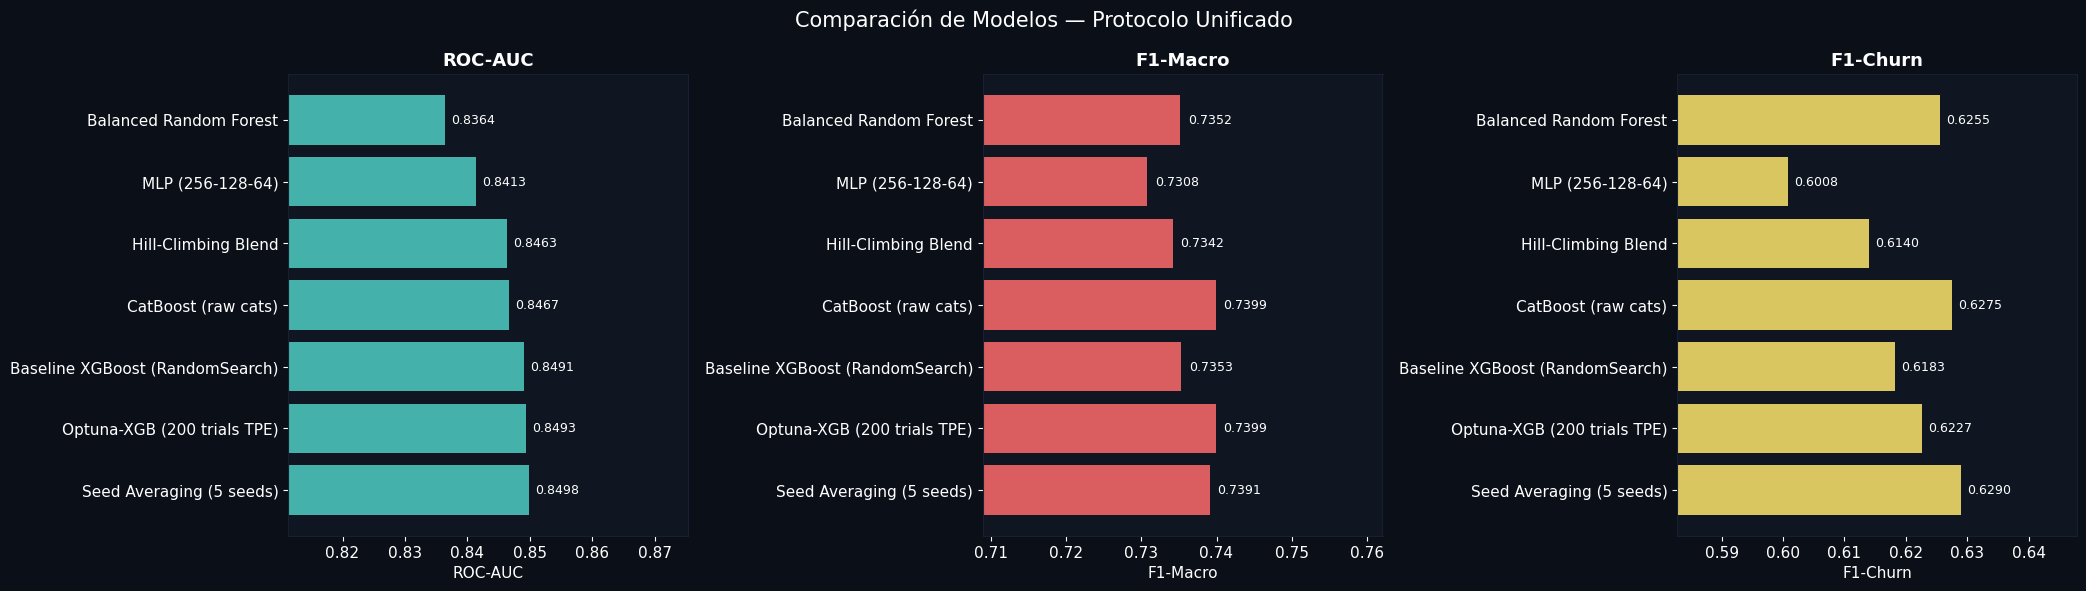

In [59]:
# ── Visual comparison ─────────────────────────────────────────────────────────
set_dark_style()
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
metrics   = ["ROC-AUC", "F1-Macro", "F1-Churn"]
colors    = ["#4ECDC4", "#FF6B6B", "#FFE66D"]

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.barh(comp_df["Modelo"], comp_df[metric], color=color, alpha=0.85)
    ax.set_xlabel(metric, color="white")
    ax.set_title(metric, color="white", fontsize=13)
    ax.tick_params(colors="white")
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", color="white", fontsize=9)
    ax.set_xlim(comp_df[metric].min() * 0.97, comp_df[metric].max() * 1.03)

plt.suptitle("Comparación de Modelos — Protocolo Unificado", color="white", fontsize=15)
plt.tight_layout()
plt.show()